## Some common abbreviations we'll be using
 - GS: Group Stage
 - KO: Knockout Stage
 - LB: Leaderboard
 - XG: Expected Goals

## Imports and Loading Data

In [1]:
from enum import Enum
from copy import copy, deepcopy
from collections.abc import Callable
from typing import Type
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
from timeit import default_timer as timer
import os
from tqdm.notebook import tqdm
from time import time

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import kagglehub
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import xgboost
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import PoissonRegressor
from scipy.stats import poisson, skellam, gaussian_kde
from scipy.special import comb
import sklearn

In [2]:
# A few utils
class Object(dict):
    def __getattr__(self, key):
        return self[key]

    def __setattr__(self, key, value):
        self[key] = value

import json
def load_json(path):
  with open(path) as f:
    obj = json.load(f)
    return obj

def load_str(path):
  with open(path) as f:
    res = f.read()
    return res

def pairify(iterable):
    it = iter(iterable)
    return list(zip(it, it))

# import logging, sys
# logging.basicConfig(
    # stream=sys.stdout,
    # level=logging.DEBUG,
    # format='%(asctime)s %(threadName)s %(message)s'
# )

In [3]:
reference = Object()

# A DataFrame representing the group stage leaderboard
reference.group_stage_leaderboard = pd.read_csv(
    "resources/data/group_stage_leaderboard.csv",
    index_col=0
)

# A list of all group stage matches
reference.group_stage_matches = load_json(
    "resources/data/group_stage_matches.json"
)

# A list of all knockout stage matches (dependant on group stage outcomes)
reference.knockout_stage_matches = load_str(
    "resources/data/knockout_stage_matches.txt"
)

# All participating teams
reference.wc_teams = eval(load_str("resources/data/teams.txt"))

# A list of all the groups and the teams in that group
reference.groups = load_json("resources/data/groups.json")

# FIFA rankings as of May 2026
reference.rankings = pd.read_csv(
    "resources/data/fifa_rankings.csv", index_col=0
)

# Only the top 8 3rd-placeed teams in the group stage advance, and their
# matchup for the round of 32 are determined by this look-up table
reference.outcomes_3rd = load_json(
    "resources/data/3rd_place_outcomes.json"
)

# Country name codes (for flag images)
reference.team_codes = load_json("resources/data/team_codes.json")

# All matches
reference.matches = load_str("resources/data/matches.json")

# Random number generator of choice
random = np.random.default_rng()

In [4]:
reference.group_stage_leaderboard

,group,points,gd,gf,rank
Mexico,A,0,0,0,-15.0
South Africa,A,0,0,0,-60.0
South Korea,A,0,0,0,-25.0
Czech Republic,A,0,0,0,-41.0
Canada,B,0,0,0,-30.0
Bosnia and Herzegovina,B,0,0,0,-65.0
Qatar,B,0,0,0,-55.0
Switzerland,B,0,0,0,-19.0
Brazil,C,0,0,0,-6.0
Morocco,C,0,0,0,-8.0


In [36]:
class UnknownTeam:
    class Type(Enum):
        pass
class Tournament:
    pass
class Team:
    pass
class Match:
    pass
class TournamentSimulator:
    pass
class Model:
    pass

class Team:
    def __init__(self, name: str):
        self.name = name
        self.ranking_points = ...
        # ...

    def __repr__(self):
        return self.name

    def get_features(self):
        return {
            "ranking_points": reference.rankings.loc[self.name, "points"]
        }

class UnknownTeam:
    class Type(Enum):
        GS_PLACEMENT = 1
        KO_ROUND_WINNER = 2
        KO_ROUND_LOSER = 3

    def __init__(self, type: UnknownTeam.Type, team: str | int,
                 tournament: Tournament):
        self.type = type
        self.team = team
        self.tournament = tournament

    def __repr__(self):
        return str(self.team)

    def ro32(team: str | int, tournament: Tournament) -> UnknownTeam:
        return UnknownTeam(UnknownTeam.Type.GS_PLACEMENT, team, tournament)

    def ko_winner(team: str | int, tournament: Tournament) -> UnknownTeam:
        return UnknownTeam(UnknownTeam.Type.KO_ROUND_WINNER, team, tournament)

    def ko_loser(team: str | int, tournament: Tournament) -> UnknownTeam:
        return UnknownTeam(UnknownTeam.Type.KO_ROUND_LOSER, team, tournament)

    def identify(self) -> Team:
        group_to_3rd_place_index = {'A':0, 'B':1, 'D':2, 'E':3,
                                'G':4, 'I':5, 'K':6, 'L':7}
        if self.type == UnknownTeam.Type.GS_PLACEMENT:
            if self.team[0] == '3':
                opponent_group = self.team[1:2]
                opponent = group_to_3rd_place_index[opponent_group]
                self.team = reference.outcomes_3rd[self.tournament.top_8_third_places][opponent]
            group = self.team[1:2]
            place = int(self.team[0])
            name = self.tournament.gs_group_lb.loc[group].index[place - 1]
            return self.tournament.teams[name]

        elif self.type == UnknownTeam.Type.KO_ROUND_WINNER:
            return self.tournament.matches[self.team].winner

        elif self.type == UnknownTeam.Type.KO_ROUND_LOSER:
            return self.tournament.matches[self.team].loser

        else:
            raise ValueError("Bad unknown team type: ", self.type)

class Match:
    def __init__(self, home: Team | UnknownTeam, away: Team | UnknownTeam):
        self.home = home
        self.away = away
        self.winner = None
        self.loser = None
        self.home_score = None
        self.away_score = None

    def __repr__(self):
        return f"{self.home.__repr__()} ({self.home_score}) vs " \
            f"{self.away.__repr__()} ({self.away_score})"

    def simulate(self, model: Type[Model], knockout=False):
        if isinstance(self.home, UnknownTeam):
            self.home = self.home.identify()
        if isinstance(self.away, UnknownTeam):
            self.away = self.away.identify()

        model = model()
        home_features, away_features = model.feature_extractor(self)
        home_xg = model.xg_predictor(home_features)
        away_xg = model.xg_predictor(away_features)
        self.home_score = model.goal_simulator(home_xg)
        self.away_score = model.goal_simulator(away_xg)

        if self.home_score > self.away_score:
            self.winner, self.loser = self.home, self.away
        elif self.home_score < self.away_score:
            self.winner, self.loser = self.away, self.home
        else:
            if knockout:
                # TODO: overtime with xg/3 ?
                winner = model.penalty_simulator(
                    home_features, away_features,
                    home_xg, away_xg
                )
                if winner == 'home':
                    self.winner, self.loser = self.home, self.away
                else:
                    self.winner, self.loser = self.away, self.home
            else:
                self.winner = self.loser = 'draw'

        model.feature_updater(self)
        return

class Tournament:
    def __init__(self, teams: dict, gs_lb: pd.DataFrame, matches: str):
        self.teams = deepcopy(teams)
        self.gs_lb = gs_lb.copy()
        self.gs_group_lb = None
        self.matches = eval(matches)
        self.top_8_third_places = None
        self.results = {} # { team: (placement, group stage stats) }
        group_count = gs_lb['group'].nunique()
        # teams_per_group = gs_lb[gs_lb['group'] == gs_lb.iloc[0, 'group']]
        self.num_gs_matches = group_count * 6
        self.num_matches = len(self.matches)
        self.num_ko_rounds = int(np.log2(self.num_matches - self.num_gs_matches+ 1))


    def gs_match(self, home, away):
        return Match(self.teams[home], self.teams[away])

    def ro32_match(self, home, away):
        return Match(UnknownTeam.ro32(home, self),
                     UnknownTeam.ro32(away, self))

    def ko_match(self, home, away):
        return Match(UnknownTeam.ko_winner(home, self),
                     UnknownTeam.ko_winner(away, self))

    def bronze(self, home, away):
        return Match(UnknownTeam.ko_loser(home, self),
                     UnknownTeam.ko_loser(away, self))

    def final(self, home, away):
        return self.ko_match(home, away)

    def simulate(self, model: Type[Model]):
        for i in range (1, self.num_matches + 1):
            match = self.matches[i]
            match.simulate(model, knockout=(i > self.num_gs_matches))
            if i <= self.num_gs_matches:
                self._update_gs_lb(match)
            if i == self.num_gs_matches:
                self._create_gs_group_lb()
            self._update_results(match, i)

    def _update_gs_lb(self, match: Match):
        if match.winner == 'draw':
            self.gs_lb.loc[match.home.name, 'points'] += 1
            self.gs_lb.loc[match.away.name, 'points'] += 1
        elif match.winner is match.home:
            self.gs_lb.loc[match.home.name, 'points'] += 3
        else:
            self.gs_lb.loc[match.away.name, 'points'] += 3
        self.gs_lb.loc[match.home.name, 'gf'] += match.home_score
        self.gs_lb.loc[match.home.name, 'gd'] += match.home_score - match.away_score
        self.gs_lb.loc[match.away.name, 'gf'] += match.away_score
        self.gs_lb.loc[match.away.name, 'gd'] += match.away_score - match.home_score

    def _create_gs_group_lb(self):
        def sort_group(group):
            """FIFA WC'26 Tie-Breakers"""
            return group.sort_values(['points', 'gd', 'gf', 'rank'],
                                     ascending=False)
        self.gs_group_lb = self.gs_lb.groupby('group') \
                                     .apply(sort_group, include_groups=False)
        third_placers = self.gs_group_lb.iloc[2::4]
        qualified = sort_group(third_placers).head(8).index.get_level_values(0)
        self.top_8_third_places = "".join(sorted([g[0] for g in qualified]))

    def _update_results(self, match: Match, index: int):
        # in group stage
        if (index := index - self.num_gs_matches) <= 0:
            return
        # in middle of knockout stage
        for r in range(self.num_ko_rounds, 1, -1):
            matches_in_round = 2**(r - 1)
            teams_in_round = 2 * matches_in_round
            if (index := index - matches_in_round) <= 0:
                self.results[match.loser.name] = teams_in_round
                return
        # 3-rd place and final
        if (index := index - 1) <= 0:
            self.results[match.loser.name] = 4
            self.results[match.winner.name] = 3
            return
        if (index := index - 1) <= 0:
            self.results[match.loser.name] = 2
            self.results[match.winner.name] = 1
            for team in self.teams.keys():
                if team not in self.results:
                    self.results[team] = 48
                placement = self.results[team]
                self.results[team] = (placement, self.gs_lb.loc[team])
            return

    def _get_flag_location(self, team_name):
        code = reference.team_codes[team_name]
        return f"./resources/flags/{code}.png"

    def _parse_tournament_data(self):
        sorted_ids = list(range(self.num_gs_matches + 1,
                                self.num_matches + 1))

        # Group sequential matches by round
        r32_matches = sorted_ids[0:16]   # 16 matches
        r16_matches = sorted_ids[16:24]  # 8 matches
        qf_matches  = sorted_ids[24:28]  # 4 matches
        sf_matches  = sorted_ids[28:30]  # 2 matches
        third_place_match = sorted_ids[30] # 1 match
        final_match = sorted_ids[31]       # 1 match

        def get_teams(match_ids):
            teams = []
            for m_id in match_ids:
                teams.append(self.matches[m_id].home.name)
                teams.append(self.matches[m_id].away.name)
            return teams

        # Round of 32 (Split 16 teams left, 16 teams right)
        r32_left = get_teams([74, 77, 73, 75, 83, 84, 81, 82])
        r32_right = get_teams([76, 78, 79, 80, 86, 88, 85, 87])

        # Round of 16 (Winners of R32)
        r16_left = get_teams([89, 90, 93, 94])
        r16_right = get_teams([91, 92, 95, 96])

        # Quarter-Finals (Winners of R16)
        qf_left = get_teams([97, 98])
        qf_right = get_teams([99, 100])

        # Semi-Finals (Winners of QF)
        sf_left = get_teams([101])
        sf_right = get_teams([102])

        # Finals & Third Place
        final_data = self.matches[104]
        finalists = [final_data.home.name, final_data.away.name]
        champion = final_data.winner.name
        third_place = self.matches[103].winner.name

        return r32_left, r32_right, r16_left, r16_right, qf_left, qf_right, sf_left, sf_right, finalists, champion, third_place

    def display_bracket(self):
        (r32_left, r32_right, r16_left, r16_right,
         qf_left, qf_right, sf_left, sf_right,
         finalists, champion, third_place) = self._parse_tournament_data()

        fig, ax = plt.subplots(figsize=(22, 14))
        fig.patch.set_facecolor('#0f172a')
        ax.set_facecolor('#0f172a')
        ax.axis('off')
        ax.set_xlim(-5, 59)
        ax.set_ylim(-4, 34)

        def add_flag(x, y, team_name, ax, zoom=0.5):
            flag_path = self._get_flag_location(team_name)
            if flag_path and os.path.exists(flag_path):
                img = mpimg.imread(flag_path)
                imagebox = OffsetImage(img, zoom=zoom)
                ab = AnnotationBbox(imagebox, (x, y), frameon=False)
                ax.add_artist(ab)
            else:
                ax.plot(x, y, 'ws', markersize=8)

        def draw_bracket_side(r32, r16, qf, sf, side="left"):
            if side == "left":
                x_cols = [0, 5, 11, 17, 22]
                direction = 1
                align = 'left'
            else:
                x_cols = [54, 49, 43, 37, 32]
                direction = -1
                align = 'right'

            # line_start dictates the gap left for text.
            # flag_line_start closes that gap for the flag-only rounds.
            line_start = 3.5 * direction
            flag_line_start = 1.0 * direction
            line_end = 0.5 * direction
            flag_spacing = 2.0 * direction

            y_r32 = list(range(30, -1, -2))

            # Draw Round of 32 (Text + Flags)
            for i, team in enumerate(r32):
                r32_align = 'right' if side == "left" else 'left'
                ax.text(x_cols[0] - (1.0 * direction), y_r32[i], team, color='white', va='center', ha=r32_align, fontsize=9, weight='bold')
                add_flag(x_cols[0] + (0.5 * direction), y_r32[i], team, ax)
                ax.plot([x_cols[0] + (1.5 * direction), x_cols[1] - line_end], [y_r32[i], y_r32[i]], color='#334155', lw=2)

            # Draw Round of 16 (Flags Only)
            y_r16 = [(y_r32[i] + y_r32[i+1])/2 for i in range(0, 16, 2)]
            for i, team in enumerate(r16):
                add_flag(x_cols[1]+flag_spacing, y_r16[i], team, ax, zoom=1)
                ax.plot([x_cols[1] - line_end, x_cols[1] - line_end], [y_r32[i*2], y_r32[i*2+1]], color='#b91c1c' if side=="left" else '#0369a1', lw=2)
                # Notice we use flag_line_start here so the line connects to the flag
                ax.plot([x_cols[1] + flag_line_start, x_cols[2] - line_end], [y_r16[i], y_r16[i]], color='#334155', lw=2)

            # Draw Quarter-Finals (Flags Only)
            y_qf = [(y_r16[i] + y_r16[i+1])/2 for i in range(0, 8, 2)]
            for i, team in enumerate(qf):
                add_flag(x_cols[2]+flag_spacing, y_qf[i], team, ax, zoom=1)
                ax.plot([x_cols[2] - line_end, x_cols[2] - line_end], [y_r16[i*2], y_r16[i*2+1]], color='#b91c1c' if side=="left" else '#0369a1', lw=2)
                ax.plot([x_cols[2] + flag_line_start, x_cols[3] - line_end], [y_qf[i], y_qf[i]], color='#334155', lw=2)

            # Draw Semi-Finals (Flags Only)
            y_sf = [(y_qf[i] + y_qf[i+1])/2 for i in range(0, 4, 2)]
            for i, team in enumerate(sf):
                add_flag(x_cols[3]+flag_spacing, y_sf[i], team, ax, zoom=1)
                ax.plot([x_cols[3] - line_end, x_cols[3] - line_end], [y_qf[i*2], y_qf[i*2+1]], color='#b91c1c' if side=="left" else '#0369a1', lw=2)
                ax.plot([x_cols[3] + flag_line_start, x_cols[4] + line_end], [y_sf[i], y_sf[i]], color='#334155', lw=2)

            # Connect to Finalist
            y_fin = (y_sf[0] + y_sf[1])/2
            ax.plot([x_cols[4] + line_end, x_cols[4] + line_end], [y_sf[0], y_sf[1]], color='#b91c1c' if side=="left" else '#0369a1', lw=2)

            return y_fin

        # 5. Render Everything
        y_final_left = draw_bracket_side(r32_left, r16_left, qf_left, sf_left, side="left")
        y_final_right = draw_bracket_side(r32_right, r16_right, qf_right, sf_right, side="right")

        # Center Elements (Flags Only for the finalists)
        ax.plot([25, 29], [y_final_left, y_final_left], color='#334155', lw=2)
        add_flag(25, y_final_left, finalists[0], ax, zoom=1)
        add_flag(29, y_final_right, finalists[1], ax, zoom=1)

        # Trophy
        trophy_path = "./resources/images/trophy.png"
        trophy_img = mpimg.imread(trophy_path)
        trophy_box = OffsetImage(trophy_img, zoom=0.25)
        trophy_ab = AnnotationBbox(trophy_box, (27, 23.5), frameon=False)
        ax.add_artist(trophy_ab)

        # Winner gets text + flag
        ax.text(27, 11, "WINNER", color='#94a3b8', va='center', ha='center', fontsize=18)
        ax.text(27, 4.5, champion.upper(), color='#fbbf24', va='center', ha='center', fontsize=30, weight='bold')
        add_flag(27, 8, champion, ax, zoom=2.5)
        plt.suptitle("FIFA 2026 WORLD CUP", color='white', fontsize=50, weight='bold', y=0.92)

        plt.tight_layout()
        plt.show()


class TournamentSimulator:
    def __init__(self,
                 num_simulations: int,
                 teams: dict,
                 gs_lb: pd.DataFrame,
                 matches: str,
                 model: Type[Model],
                 max_workers=None):
        self.run = False
        self.num = num_simulations
        self.teams = teams
        self.gs_lb = gs_lb
        self.matches = matches
        self.model = model
        self.max_workers = max_workers
        self.all_placements = None
        self.summary = None
        self.avg_gs_lb = None

    def simulate(self):
        n = self.num
        # with ThreadPoolExecutor(max_workers=self.max_workers) as executor:
            # all_placements = list(tqdm(
                # executor.map(self._run_a_simulation, range(n)),
                # total=n,
                # desc='Simulating'
            # ))

        futures = []
        with ThreadPoolExecutor(max_workers=self.max_workers) as executor:
            for i in range(n):
                futures.append(executor.submit(self._run_a_simulation, i))
        
                all_placements = []
                for future in tqdm(as_completed(futures), total=n, desc='Simulating'):
                    all_placements.append(future.result())


        self.summary, self.avg_gs_lb = self._aggregrate(all_placements)

    def _run_a_simulation(self: TournamentSimulator, _) -> dict:
        # logging.debug(f"starting")
        t = Tournament(self.teams, self.gs_lb, self.matches)
        # logging.debug(f"tournament created")
        t.simulate(self.model)
        # logging.debug(f"simulation done")
        return t.results

    def _aggregrate(self, all_placements: list[dict]) -> tuple[pd.DataFrame, pd.DataFrame]:
        n = self.num
        counts = defaultdict(lambda: defaultdict(int))
        gs_lb = reference.group_stage_leaderboard.copy().drop(columns=['group'])

        for result in tqdm(all_placements, total=n, desc='Aggregating'):
            for team, [place, gs_results] in result.items():
                gs_lb.loc[team] += gs_results
                # if place < 48:  counts[team]["Group Stage"] += 1
                if place <= 32: counts[team]["Round of 32"] += 1
                if place <= 16: counts[team]["Round of 16"] += 1
                if place <= 8:  counts[team]["Quarter-Finals"] += 1
                if place <= 4:  counts[team]["Semi-Finals"] += 1
                if place <= 2:  counts[team]["Finals"] += 1
                if place == 1:  counts[team]["Win"] += 1

        df = pd.DataFrame.from_dict(counts, orient="index") \
                         .fillna(0).astype(int)
        df = df[["Win", "Finals", "Semi-Finals", "Quarter-Finals",
                 "Round of 16", "Round of 32"]]
        df = df * 100.0 / n
        df = df.sort_values("Win", ascending=False)

        gs_lb = gs_lb / n

        return df, gs_lb

class Model:
    def feature_extractor(self, match: Match) -> tuple[dict, dict]:
        raise NotImplementedError

    def xg_predictor(self, match_features: dict) -> float:
        raise NotImplementedError

    def goal_simulator(self, xg: float) -> int:
        raise NotImplementedError

    def penalty_simulator(self, *args) -> str:
        raise NotImplementedError

    def feature_updater(self, match: Match):
        raise NotImplementedError

class TotallyRandom(Model):
    def feature_extractor(self, match: Match) -> tuple[dict, dict]:
        return ({}, {})

    def xg_predictor(self, match_features: dict) -> float:
        return 6 * random.random()

    def goal_simulator(self, xg: float) -> int:
        return int(xg)

    def penalty_simulator(self, *args) -> str:
        n = random.random()
        if n < 0.5:
            return 'home'
        else:
            return 'away'

    def feature_updater(self, match: Match):
        pass

class RankIsEverything(Model):
    def feature_extractor(self, match: Match) -> tuple[dict, dict]:
        return ({'team_ranking': reference.rankings.loc[match.home.name, 'points'],
                 'opponent_ranking': reference.rankings.loc[match.away.name, 'points']},
                {'team_ranking': reference.rankings.loc[match.away.name, 'points'],
                 'opponent_ranking': reference.rankings.loc[match.home.name, 'points']})

    def xg_predictor(self, match_features: dict) -> float:
        home_points = match_features["team_ranking"]
        away_points = match_features["opponent_ranking"]
        if home_points > away_points:
            return 1
        else:
            return 0

    def goal_simulator(self, xg: float) -> int:
        return int(xg)

    def penalty_simulator(self, *args) -> str:
        return 'home' # doesnt matter, theres always a winner

    def feature_updater(self, match: Match):
        pass

In [ ]:
# Lookup table of team names to Team objects
reference.teams = {
    name: Team(name) for name in reference.wc_teams
}

0.08212991100117506
2026-05-27 10:09:42,115 MainThread Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-27 10:09:42,117 MainThread Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-27 10:09:42,120 MainThread findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-05-27 10:09:42,120 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFiveSymReg.ttf', name='STIXSizeFiveSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-05-27 10:09:42,121 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/cmb10.ttf', name='cmb10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-05-27 10:09:42,12

2026-05-27 10:09:42,133 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/cmmi10.ttf', name='cmmi10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-05-27 10:09:42,133 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralItalic.ttf', name='STIXGeneral', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-05-27 10:09:42,133 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-05-27 10:09:42,134 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cu

2026-05-27 10:09:42,144 MainThread findfont: score(FontEntry(fname='/usr/share/fonts/Adwaita/AdwaitaSans-Regular.ttf', name='Adwaita Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-05-27 10:09:42,144 MainThread findfont: score(FontEntry(fname='/usr/share/fonts/gnu-free/FreeMonoBoldOblique.otf', name='FreeMono', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-05-27 10:09:42,144 MainThread findfont: score(FontEntry(fname='/usr/share/fonts/TTF/AdwaitaMonoNerdFontMono-BoldItalic.ttf', name='AdwaitaMono Nerd Font Mono', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-05-27 10:09:42,145 MainThread findfont: score(FontEntry(fname='/usr/share/fonts/gnu-free/FreeSansBold.otf', name='FreeSans', style='normal', variant='normal', weight=600, stretch='normal', size='scalable')) = 10.24
2026-05-27 10:09:42,145 MainThread findfont: score(FontEntry(fnam

2026-05-27 10:09:42,259 MainThread STREAM b'IDAT' 41 560
2026-05-27 10:09:42,261 MainThread STREAM b'IHDR' 16 13
2026-05-27 10:09:42,261 MainThread STREAM b'IDAT' 41 934
2026-05-27 10:09:42,263 MainThread STREAM b'IHDR' 16 13
2026-05-27 10:09:42,263 MainThread STREAM b'IDAT' 41 567
2026-05-27 10:09:42,265 MainThread STREAM b'IHDR' 16 13
2026-05-27 10:09:42,265 MainThread STREAM b'IDAT' 41 1559
2026-05-27 10:09:42,267 MainThread STREAM b'IHDR' 16 13
2026-05-27 10:09:42,267 MainThread STREAM b'IDAT' 41 118
2026-05-27 10:09:42,269 MainThread STREAM b'IHDR' 16 13
2026-05-27 10:09:42,270 MainThread STREAM b'IDAT' 41 577
2026-05-27 10:09:42,271 MainThread STREAM b'IHDR' 16 13
2026-05-27 10:09:42,272 MainThread STREAM b'IDAT' 41 1346
2026-05-27 10:09:42,274 MainThread STREAM b'IHDR' 16 13
2026-05-27 10:09:42,274 MainThread STREAM b'IDAT' 41 383
2026-05-27 10:09:42,276 MainThread STREAM b'IHDR' 16 13
2026-05-27 10:09:42,276 MainThread STREAM b'IDAT' 41 2121
2026-05-27 10:09:42,278 MainThread S

2026-05-27 10:09:42,366 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-BoldOblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.05
2026-05-27 10:09:42,366 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymBol.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.05
2026-05-27 10:09:42,367 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Bold.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 0.05
2026-05-27 10:09:42,367 MainThread findfont: score(FontE

...

2026-05-27 10:09:42,444 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sans Mono', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
2026-05-27 10:09:42,445 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-Bold.ttf', name='DejaVu Sans Mono', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.05
2026-05-27 10:09:42,445 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-Oblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.335
2026-05-27 10:09:42,446 MainThread findfont: sco

2026-05-27 10:09:42,453 MainThread findfont: score(FontEntry(fname='/usr/share/fonts/gnu-free/FreeSerifBold.otf', name='FreeSerif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.05
2026-05-27 10:09:42,453 MainThread findfont: score(FontEntry(fname='/usr/share/fonts/gnu-free/FreeSerifItalic.otf', name='FreeSerif', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.335
2026-05-27 10:09:42,454 MainThread findfont: score(FontEntry(fname='/usr/share/fonts/Adwaita/AdwaitaMono-Regular.ttf', name='Adwaita Mono', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
2026-05-27 10:09:42,454 MainThread findfont: score(FontEntry(fname='/usr/share/fonts/gnu-free/FreeSerifBoldItalic.otf', name='FreeSerif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.05
2026-05-27 10:09:42,454 MainThread findfont: score(FontEntry(fname='/usr/share/fonts/gnu-free/

2026-05-27 10:09:42,469 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
2026-05-27 10:09:42,469 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniBolIta.ttf', name='STIXNonUnicode', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.05
2026-05-27 10:09:42,469 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymReg.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
2026-05-27 10:09:42,470 MainThread findfont: score(FontEnt

2026-05-27 10:09:42,476 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralBolIta.ttf', name='STIXGeneral', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.05
2026-05-27 10:09:42,476 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Oblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 1.335
2026-05-27 10:09:42,476 MainThread findfont: score(FontEntry(fname='/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizTwoSymReg.ttf', name='STIXSizeTwoSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
2026-05-27 10:09:42,476 MainThread findfont: score(FontEntry(fnam

2026-05-27 10:09:42,484 MainThread findfont: score(FontEntry(fname='/usr/share/fonts/gnu-free/FreeMono.otf', name='FreeMono', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
2026-05-27 10:09:42,484 MainThread findfont: score(FontEntry(fname='/usr/share/fonts/gnu-free/FreeSansBoldOblique.otf', name='FreeSans', style='oblique', variant='normal', weight=600, stretch='normal', size='scalable')) = 11.145
2026-05-27 10:09:42,484 MainThread findfont: score(FontEntry(fname='/usr/share/fonts/TTF/AdwaitaMonoNerdFont-Italic.ttf', name='AdwaitaMono Nerd Font', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.335
2026-05-27 10:09:42,484 MainThread findfont: Matching sans\-serif:style=normal:variant=normal:weight=bold:stretch=normal:size=50.0 to DejaVu Sans ('/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Bold.ttf') with score of 0.050000.


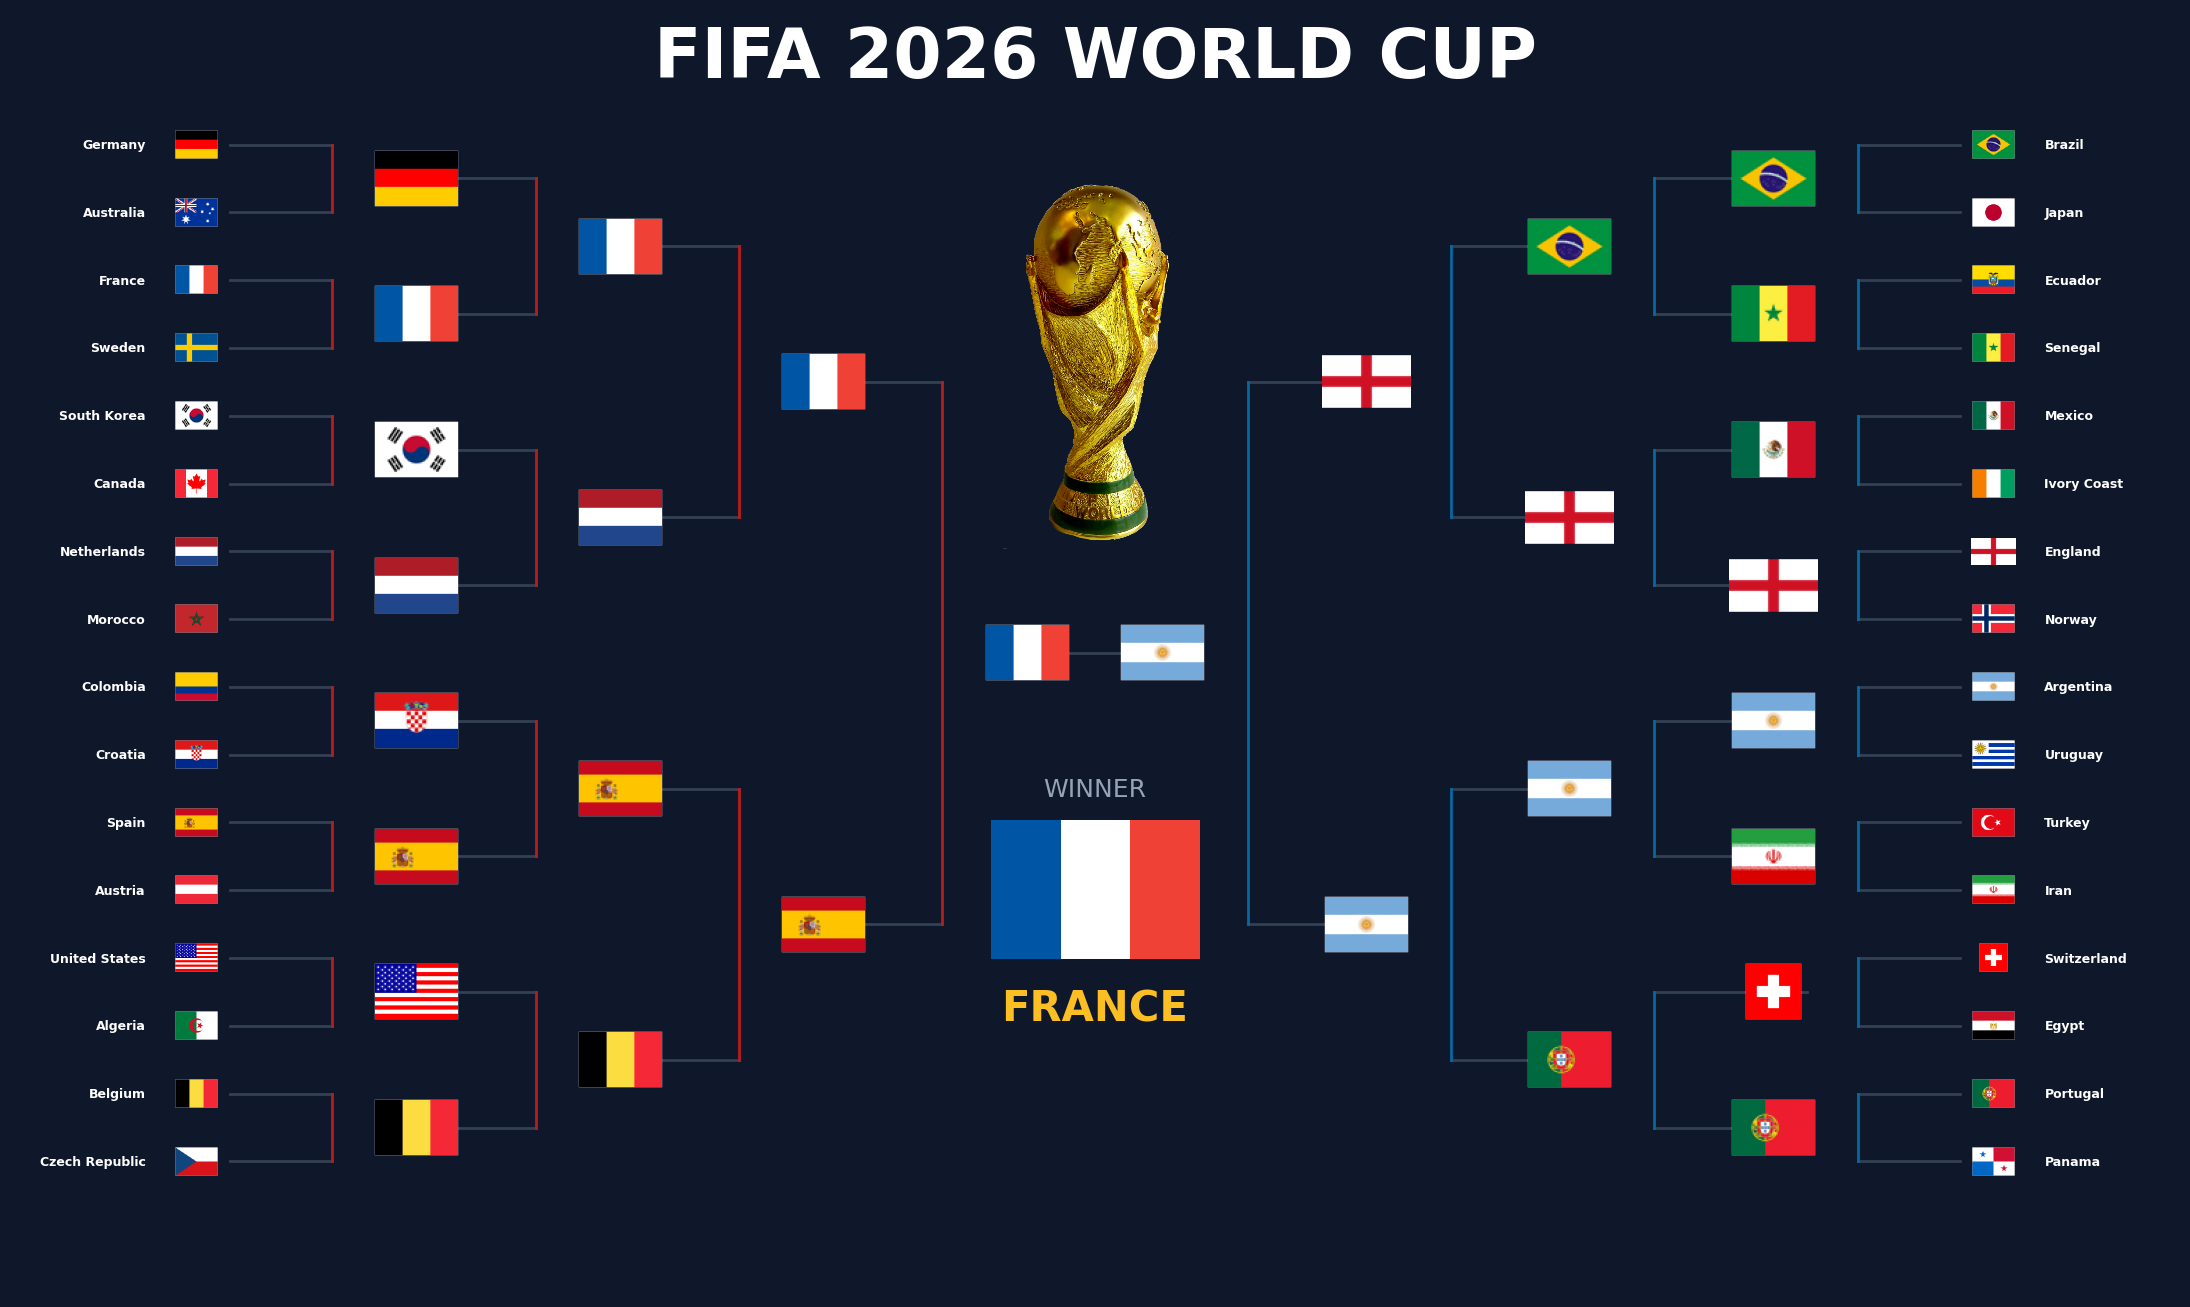

In [6]:
start = timer()
t = Tournament(
    teams=reference.teams,
    gs_lb=reference.group_stage_leaderboard,
    matches=reference.matches
)
t.simulate(RankIsEverything)
end = timer()
print(end - start)

# t.results
t.display_bracket()

In [7]:
start = timer()
s = TournamentSimulator(
    num_simulations   = 100,
    teams             = reference.teams,
    gs_lb             = reference.group_stage_leaderboard,
    matches           = reference.matches,
    model             = TotallyRandom
)
s.simulate()
end = timer()
print(end - start)
s.summary

2026-05-27 10:09:42,817 ThreadPoolExecutor-0_0 starting
2026-05-27 10:09:42,821 ThreadPoolExecutor-0_0 tournament created


Simulating:   0%|          | 0/100 [00:00<?, ?it/s]

2026-05-27 10:09:42,883 ThreadPoolExecutor-0_0 simulation done
2026-05-27 10:09:42,892 ThreadPoolExecutor-0_0 starting
2026-05-27 10:09:42,895 ThreadPoolExecutor-0_0 tournament created


Simulating:   0%|          | 0/100 [00:00<?, ?it/s]

2026-05-27 10:09:42,949 ThreadPoolExecutor-0_0 simulation done
2026-05-27 10:09:42,952 ThreadPoolExecutor-0_0 starting
2026-05-27 10:09:42,959 ThreadPoolExecutor-0_0 tournament created


...

Simulating:   0%|          | 0/100 [00:00<?, ?it/s]

2026-05-27 10:09:48,551 ThreadPoolExecutor-0_0 simulation done


Aggregating:   0%|          | 0/100 [00:00<?, ?it/s]

9.070967350999126


,Win,Finals,Semi-Finals,Quarter-Finals,Round of 16,Round of 32
Morocco,5.0,6.0,12.0,19.0,32.0,70.0
Qatar,5.0,8.0,13.0,19.0,38.0,66.0
Paraguay,4.0,6.0,14.0,24.0,38.0,63.0
Ghana,4.0,6.0,10.0,19.0,35.0,59.0
Sweden,4.0,8.0,10.0,18.0,34.0,62.0
Japan,3.0,3.0,8.0,25.0,36.0,71.0
Jordan,3.0,4.0,9.0,15.0,31.0,69.0
Scotland,3.0,5.0,7.0,13.0,27.0,69.0
Ecuador,3.0,4.0,13.0,18.0,34.0,60.0
Iran,3.0,6.0,11.0,20.0,40.0,74.0


In [8]:
data = Object()
path = kagglehub.dataset_download("martj42/international-football-results-from-1872-to-2017")
data.results = pd.read_csv(os.path.join(path, "results.csv"))
data.goalscorers = pd.read_csv(os.path.join(path, "goalscorers.csv"))
data.shootouts = pd.read_csv(os.path.join(path, "shootouts.csv"))
path = kagglehub.dataset_download("cashncarry/fifaworldranking")
data.ranking_history = pd.read_csv(os.path.join(path, "fifa_ranking-2024-06-20.csv"))
data.rankings = pd.read_csv("resources/data/fifa_rankings.csv", index_col=0)

2026-05-27 10:09:52,140 MainThread Starting new HTTPS connection (1): api.kaggle.com:443
2026-05-27 10:09:52,421 MainThread https://api.kaggle.com:443 "POST /v1/datasets.DatasetApiService/GetDataset HTTP/1.1" 200 None
2026-05-27 10:09:52,630 MainThread Starting new HTTPS connection (1): api.kaggle.com:443
2026-05-27 10:09:52,985 MainThread https://api.kaggle.com:443 "POST /v1/datasets.DatasetApiService/GetDataset HTTP/1.1" 200 None


In [9]:
data.results = data.results.dropna().reset_index(drop=True)
# Keeping only results from 1970 because modern (TODO explain)
data.results = data.results[data.results['date'] > '1970-01-01'].reset_index(drop=True)

In [10]:
# we count every time a team has played at home and away
home_games_played = data.results['home_team'].value_counts()
away_games_played = data.results['away_team'].value_counts()

# we each teams' total games played by combining home and away games played
games_played = pd.concat([home_games_played, away_games_played]).groupby(level=0).sum()

# now we add it back into the results
data.results['home_team_games_played'] = data.results['home_team'].apply(lambda t: games_played[t])
data.results['away_team_games_played'] = data.results['away_team'].apply(lambda t: games_played[t])

# keep only teams with 200 games played in past 45 years (5 games/year)
# and fricking Curaçao has only player 215 since 1970
data.results = data.results[
    (data.results['home_team_games_played'] > 200) &
    (data.results['away_team_games_played'] > 20)
].reset_index(drop=True)

In [11]:
confedrational_tournaments = ['UEFA Euro', 'African Cup of Nations', 'AFC Asian Cup', 'CONCACAF Championship',
                              'Copa América', 'Gold Cup','Oceania Nations Cup', 'Confederations Cup']

qualifiers = ['AFC Asian Cup qualification', 'African Cup of Nations qualification',
                  'Gold Cup qualification', 'CONCACAF Championship qualification',
                  'Copa América qualification', 'FIFA World Cup qualification', 'Oceania Nations Cup qualification',
                  'UEFA Euro qualification']

nations_league = ['CONCACAF Nations League', 'CONCACAF Nations League qualification', 'UEFA Nations League']


tournament_categories = defaultdict(lambda: 'Friendlies/Low-Importance Competitions')

for t in confedrational_tournaments:
    tournament_categories[t] = 'Confederational Tournament'

for t in qualifiers:
    tournament_categories[t] = 'Nations League/Confederational Cup Qualifiers/WC Qualifiers'

for t in nations_league:
    tournament_categories[t] = 'Nations League/Confederational Cup Qualifiers/WC Qualifiers'

tournament_categories['FIFA World Cup'] = 'FIFA World Cup'

data.results['category'] = data.results.tournament.apply(lambda x: tournament_categories[x])

importances = {
    'FIFA World Cup': 1.0,
    'Confederational Tournament': 0.85,
    'Nations League/Confederational Cup Qualifiers/WC Qualifiers': 0.65,
    'Friendlies/Low-Importance Competitions': 0.5,
}

data.results['importance'] = data.results.category.apply(lambda x: importances[x])

In [12]:
# frickin Bermuda doesn't play at home
all_teams = list(
    set(data.results['home_team'].unique()) |
    set(data.results['away_team'].unique())
)
num_all_teams = len(all_teams)
ratings = {name: 0.0 for name in all_teams}
asi = {name: 0.0 for name in all_teams}
dwi = {name: 0.0 for name in all_teams}
form = {name: np.zeros(shape=(5, 3)) for name in all_teams}
data.results['home_rating'] = None
data.results['home_asi'] = None
data.results['home_dwi'] = None
data.results['home_form'] = None
data.results['away_rating'] = None
data.results['away_asi'] = None
data.results['away_form'] = None

matches_played = {name: 0 for name in all_teams}
teams_at_5_games_played = 0
all_teams_5_games_index = -1

def calculate_new_rating(match):
    team1 = match['home_team']
    team2 = match['away_team']

    # ratings
    r1 = ratings[team1]
    r2 = ratings[team2]

    # scores
    g1 = match['home_score']
    g2 = match['away_score']

    # match result
    gd = g1 - g2
    W1 = 1 if gd > 0 else 0.5 if gd == 0 else 0
    W2 = 1 - W1

    # expected result
    d = r1 - r2
    try:
        We1 = 1 / (1 + 10**(-d))
    except:
        We1 = 0 if d < 0 else 1
    We2 = 1 - We1

    # some scalar
    a = 0.1
    # importance
    i = match['importance']

    r1 = r1 + a * i * (W1 - We1)
    r2 = r2 + a * i * (W2 - We2)

    # update the latest rating
    return r1, r2

def calculate_new_asi(match):
    t1 = match['home_team']
    t2 = match['away_team']

    asi1 = asi[t1]
    asi2 = asi[t2]

    dwi1 = dwi[t1]
    dwi2 = dwi[t2]

    g1 = match['home_score']
    g2 = match['away_score']

    k = 2
    sig1 = 1 / (k ** (-dwi2) + 1)
    sig2 = 1 / (k ** (-dwi1) + 1)

    a = 0.25
    i = match['importance']
    u1 = a * i * (1.5 - sig1)
    u2 = a * i * (1.5 - sig2)

    asi1 = u1 * g1 + (1 - u1) * asi1
    asi2 = u2 * g2 + (1 - u2) * asi2

    return asi1, asi2

def calculate_new_dwi(match):
    t1 = match['home_team']
    t2 = match['away_team']

    asi1 = asi[t1]
    asi2 = asi[t2]

    dwi1 = dwi[t1]
    dwi2 = dwi[t2]

    g1 = match['home_score']
    g2 = match['away_score']

    k = 2
    sig1 = 1 / (k ** (-asi2) + 1)
    sig2 = 1 / (k ** (-asi1) + 1)

    a = 0.25
    i = match['importance']
    u1 = a * i * (1.5 - sig1)
    u2 = a * i * (1.5 - sig2)

    dwi1 = u1 * g1 + (1 - u1) * dwi1
    dwi2 = u2 * g2 + (1 - u2) * dwi2

    return dwi1, dwi2

def calculate_new_form(match):
    t1 = match['home_team']
    t2 = match['away_team']

    f1 = form[t1]
    f2 = form[t2]

    f1 = np.roll(f1, 3)
    f2 = np.roll(f2, 3)

    g1 = match['home_score']
    g2 = match['away_score']
    gd = g1 - g2

    r1 = match['home_rating']
    r2 = match['away_rating']

    rd1 = 1 / (math.exp(r2 - r1))
    rd2 = 1 / (math.exp(r1 - r2))

    i = match['importance']

    f1[0] = [ gd, i, rd1]
    f2[0] = [-gd, i, rd2]


    return f1, f2

def eval_form(f):
    return float(sum([gd * i * rd for gd, i, rd in f]))

def as_is(x):
    return x

for i, row in tqdm(data.results.iterrows(), total=data.results.shape[0], desc='Calculating ratings'):
    home = row['home_team']
    away = row['away_team']

    todos = [
        ("rating", calculate_new_rating, ratings, as_is),
        ("asi",    calculate_new_asi,    asi,     as_is),
        ("dwi",    calculate_new_dwi,    dwi,     as_is),
        ("form",   calculate_new_form,   form,    eval_form),
    ]
    for col_name, updater, table, evaluator in todos:
        # get the stat
        home_stat = table[home]
        away_stat = table[away]

        data.results.loc[i, 'home_'+col_name] = evaluator(home_stat)
        row['home_'+col_name] = evaluator(home_stat)
        data.results.loc[i, 'away_'+col_name] = evaluator(away_stat)
        row['away_'+col_name] = evaluator(away_stat)

        # update the stat
        home_stat, away_stat = updater(row)
        table[home] = home_stat
        table[away] = away_stat

    matches_played[home] += 1
    if (matches_played[home] == 5):
        teams_at_5_games_played += 1
    matches_played[away] += 1
    if (matches_played[away] == 5):
        teams_at_5_games_played += 1
    if teams_at_5_games_played == num_all_teams \
       and all_teams_5_games_index == -1:
        all_teams_5_games_index = i

Calculating ratings:   0%|          | 0/37355 [00:00<?, ?it/s]

In [37]:
for team in reference.wc_teams:
    reference.teams[team].rating = ratings[team]
    reference.teams[team].asi = asi[team]
    reference.teams[team].dwi = dwi[team]
    reference.teams[team].form = form[team]

In [14]:
relevant_results = data.results[data.results.index > all_teams_5_games_index].reset_index(drop=True)
relevant_results

entries = []
for i, row in tqdm(relevant_results.iterrows(), total=relevant_results.shape[0], desc='Creating training data'):
    date = row['date']
    team1 = row['home_team']
    team2 = row['away_team']
    team1_score = row['home_score']
    team2_score = row['away_score']
    r1 = row['home_rating']
    r2 = row['away_rating']
    asi1 = row['home_asi']
    asi2 = row['away_asi']
    dwi1 = row['home_dwi']
    dwi2 = row['away_dwi']
    f1 = row['home_form']
    f2 = row['away_form']
    i = row['importance']
    venue = 0 if row['neutral'] else 2int(team1 == row['country'])

    # trying predict how many goals team1 scored
    entries.append({
        'date': date,
        'team': team1,
        'opponent': team2,
        'team_rating': r1,
        'opponent_rating': r2,
        'team_asi': asi1,
        'opponent_dwi': dwi2,
        'team_form': f1,
        'opponent_form': f2,
        'importance': i,
        'venue': venue,
        'goals_scored': team1_score
    })

    # now for teaem2
    entries.append({
        'date': date,
        'team': team2,
        'opponent': team1,
        'team_rating': r2,
        'opponent_rating': r1,
        'team_asi': asi2,
        'opponent_dwi': dwi1,
        'team_form': f2,
        'opponent_form': f1,
        'importance': i,
        'venue': 1 - venue,
        'goals_scored': team2_score
    })

data.entries = pd.DataFrame(entries)

Creating training data:   0%|          | 0/37355 [00:00<?, ?it/s]

In [15]:
def mean_log_likelihood(goals, lambdas):
    goals = np.asarray(goals)
    lambdas = np.asarray(lambdas)

    return poisson.logpmf(goals, lambdas).mean()
mll = mean_log_likelihood

def negative_expected_calibration_error(goals, lambdas, n_bins=10):
    goals = np.asarray(goals)
    lambdas = np.asarray(lambdas)

    order = np.argsort(lambdas)
    goals = goals[order]
    lambdas = lambdas[order]

    N = len(goals)
    bins = np.array_split(np.arange(N), n_bins)

    ece = 0.0

    for idx in bins:
        if len(idx) == 0:
            continue

        mean_goals = goals[idx].mean()
        mean_lambda = lambdas[idx].mean()

        ece += (len(idx) / N) * abs(mean_goals - mean_lambda)

    return -ece
nece = negative_expected_calibration_error

def negative_log_loss_1X2(goals, lambdas, eps=1e-15):
    scores = pairify(goals)
    lambdas_in_pairs = pairify(lambdas)
    losses = []

    for (g1, g2), (lam1, lam2) in zip(scores, lambdas_in_pairs):
        p_draw = skellam.pmf(0, lam1, lam2)
        p_home = 1 - skellam.cdf(0, lam1, lam2)
        p_away = skellam.cdf(-1, lam1, lam2)

        p_home = np.clip(p_home, eps, 1 - eps)
        p_draw = np.clip(p_draw, eps, 1 - eps)
        p_away = np.clip(p_away, eps, 1 - eps)

        # pick realized outcome
        if g1 > g2:
            p = p_home
        elif g1 == g2:
            p = p_draw
        else: # g1 < g2
            p = p_away

        losses.append(-np.log(p))

    return -np.mean(losses)
nll1x2 = negative_log_loss_1X2

def probability_integral_transform(goals, lambdas, random_state=42):
    goals = np.asarray(goals)
    lambdas = np.asarray(lambdas)

    rng = np.random.default_rng(random_state)

    u = rng.random(len(goals))

    pit = (
        poisson.cdf(goals - 1, lambdas)
        + u * poisson.pmf(goals, lambdas)
    )

    return pit
def plot_pit_histogram(pit_values, bins=10):
    plt.figure(figsize=(6, 4))
    plt.hist(pit_values, bins=bins, range=(0, 1), edgecolor="black")
    plt.xlabel("PIT value")
    plt.ylabel("Frequency")
    plt.title("PIT Histogram")
    plt.tight_layout()
    plt.show()
pit = probability_integral_transform

In [16]:
class ModelValidator:
    def __init__(self, xg_predictor_callable, data, goals, goal_generator_callable=None, fixed_lambdas=None, window_length=2000):
        self.build_xg_predictor = xg_predictor_callable
        self.data = data
        self.goals = goals
        self.build_goal_generator = goal_generator_callable
        self.fixed_lambdas = fixed_lambdas
        self.WINDOW_LENGTH = window_length
        self.summary = {}

    def get_summary(self):
        return self.summary.copy()

    def evaluate_xg_predictor(self, goals, lambdas):
        return {
            'mll': mll(goals, lambdas),
            'nece': nece(goals, lambdas),
            'nll1x2': nll1x2(goals, lambdas),
            'pit': pit(goals, lambdas)
        }

    def plot_xg_predictor_summary(self):
        summary = self.summary

        mlls = summary.get('mlls', [])
        nll1x2 = summary.get('nll1x2', [])
        neces = summary.get('neces', [])
        train_times = summary.get('training-times', [])
        infer_times = summary.get('inference-times', [])
        pits = summary.get('pits', [])

        n = len(mlls)
        x = np.arange(1, n + 1)

        fig = plt.figure(figsize=(18, 16))
        fig.suptitle("xG Predictor Validation Summary", fontsize=18)

        gs = fig.add_gridspec(
            nrows=4,
            ncols=6,
            height_ratios=[1, 1, 1, 1.1]
        )

        ax_mll = fig.add_subplot(gs[0, 1:5])
        ax_mll.plot(x, mlls, marker='o')
        ax_mll.set_title("Mean Log-Likelihood (MLL)")
        ax_mll.set_xlabel("Window")
        ax_mll.grid(True)

        ax_nll1x2 = fig.add_subplot(gs[1, 0:3])
        ax_nll1x2.plot(x, nll1x2, marker='o')
        ax_nll1x2.set_title("Negative Log-Loss (1X2)")
        ax_nll1x2.set_xlabel("Window")
        ax_nll1x2.grid(True)

        ax_nece = fig.add_subplot(gs[1, 3:6])
        ax_nece.plot(x, neces, marker='o')
        ax_nece.set_title("Negative ECE (NECE)")
        ax_nece.set_xlabel("Window")
        ax_nece.grid(True)

        ax_train = fig.add_subplot(gs[2, 0:3])
        ax_train.plot(x, train_times, marker='o')
        ax_train.set_title("Training Time")
        ax_train.set_xlabel("Window")
        ax_train.set_ylabel("Seconds")
        ax_train.grid(True)

        ax_infer = fig.add_subplot(gs[2, 3:6])
        ax_infer.plot(x, infer_times, marker='o')
        ax_infer.set_title("Inference Time")
        ax_infer.set_xlabel("Window")
        ax_infer.set_ylabel("Seconds")
        ax_infer.grid(True)

        if pits:
            n_pits = len(pits)

            idxs = [
                0,
                n_pits // 4,
                n_pits // 2,
                (3 * n_pits) // 4,
                n_pits - 1
            ]

            titles = [
                "First window",
                "End of 1st quarter",
                "Middle",
                "Start of final quarter",
                "Last window"
            ]

            for i, (idx, title) in enumerate(zip(idxs, titles)):
                ax = fig.add_subplot(gs[3, i])
                ax.hist(pits[idx], bins=10, range=(0, 1), edgecolor='black')
                ax.set_title(title)
                ax.set_xlabel("PIT")
                ax.grid(True)

            fig.axes[-5].set_ylabel("Count")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    def validate(self):
        data = self.data
        goals = self.goals
        N = len(data)
        n_windows = N // self.WINDOW_LENGTH + 1
        summary = self.summary

        summary['training-times'], summary['inference-times'] = [], []

        if self.build_goal_generator is None:
            summary['mlls'], summary['neces'], summary['nll1x2'], summary['pits'] = [], [], [], []

        else:
            summary['gg-training-times'], summary['gg-inference-times'] = [], []
            summary['hits'], summary['1X2'], summary['nmse'], summary['gambler'], summary['nw2d'] = [], [], [], [], []
            summary['scores-analysis'], summary['preds-analysis'] = [], []


        for i in range(n_windows - 1):
            print(f'\n({i + 1})')
            train_data = data[: (i + 1) * self.WINDOW_LENGTH]
            train_goals = goals[: (i + 1) * self.WINDOW_LENGTH]

            test_data = data[(i + 1) * self.WINDOW_LENGTH: min(N, (i + 2) * self.WINDOW_LENGTH)]
            test_goals = goals[(i + 1) * self.WINDOW_LENGTH: min(N, (i + 2) * self.WINDOW_LENGTH)]

            xg_predictor = self.build_xg_predictor()

            before = time()
            xg_predictor.fit(train_data, train_goals)
            summary['training-times'].append(time() - before)
            print(f"xG Predictor training time: {summary['training-times'][-1]:.4f}")

            before = time()
            lambdas = xg_predictor.predict(test_data)
            summary['inference-times'].append(time() - before)
            print(f"xG Predictor inference time: {summary['inference-times'][-1]:.4f}")

            if self.build_goal_generator is None:
                # goal generator is not provided
                # we will only evaluate xg predictor
                eval_dict = self.evaluate_xg_predictor(test_goals, lambdas)
                summary['mlls'].append(eval_dict['mll'])
                summary['neces'].append(eval_dict['nece'])
                summary['nll1x2'].append(eval_dict['nll1x2'])
                summary['pits'].append(eval_dict['pit'])
                print(f"xG Predictor Mean Log Likelihood: {summary['mlls'][-1]:.4f}")
                print(f"xG Predictor Negative Log-Loss 1X2: {summary['nll1x2'][-1]:.4f}")
                print(f"xG Predictor Negative Expected Calibration Error: {summary['neces'][-1]:.4f}")

            else:
                # our goal is to evaluate goal generator
                goal_generator = self.build_goal_generator()
                train_lambdas = self.fixed_lambdas[(i + 1) * self.WINDOW_LENGTH: min(N, (i + 2) * self.WINDOW_LENGTH)]
                train_lambdas_in_pairs = pairify(train_lambdas)
                train_scores = pairify(train_goals)
                before = time()
                goal_generator.fit(train_lambdas_in_pairs, train_scores)
                summary['gg-training-times'].append(time() - before)
                print(f"Goal Generator training time: {summary['gg-training-times'][-1]:.4f}")
                lambdas_in_pairs = pairify(lambdas)
                before = time()
                preds = goal_generator.predict(lambdas_in_pairs)
                summary['gg-inference-times'].append(time() - before)
                print(f"Goal Generator inference time: {summary['gg-inference-times'][-1]:.4f}")
                test_scores = pairify(test_goals)
                eval_dict = self.evaluate_goal_generator(test_scores, preds)
                summary['hits'].append(eval_dict['hits'])
                summary['1X2'].append(eval_dict['1X2'])
                summary['nmse'].append(eval_dict['nmse'])
                summary['gambler'].append(eval_dict['gambler'])
                summary['nw2d'].append(eval_dict['nw2d'])
                summary['scores-analysis'].append(eval_dict['scores-analysis'])
                summary['preds-analysis'].append(eval_dict['preds-analysis'])
                print(f"Goal Generator Hits Ratio: {summary['hits'][-1]:.4f}")
                print(f"Goal Generator 1X2 Success Ratio: {summary['1X2'][-1]:.4f}")
                print(f"Goal Generator Negative Mean Squared Error: {summary['nmse'][-1]:.4f}")
                print(f"Goal Generator Gambler Rating: {summary['gambler'][-1]:.4f}")
                print(f"Goal Generator Negative Wasserstein 2D: {summary['nw2d'][-1]:.4f}")

In [54]:
maher_features = ['team_asi', 'opponent_dwi', 'venue']
most_features = ['team_rating', 'team_asi', 'opponent_dwi', 'importance']#, 'venue']
all_features = ['team_rating', 'team_asi', 'opponent_dwi', 'team_form', 'opponent_form', 'importance']#, 'venue']

summaries = Object()
# 'Dummy Regressor': dr_summary,
# 'Maher Model': mm_summary,
# 'Poisson Regressor': pr_summary,
# 'Poisson XGBRegressor Maher': pxgbr_maher_summary,
# 'Poisson XGBRegressor': pxgbr_summary,


(1)
xG Predictor training time: 0.0005
xG Predictor inference time: 0.0001
xG Predictor Mean Log Likelihood: -1.6751
xG Predictor Negative Log-Loss 1X2: -1.0728
xG Predictor Negative Expected Calibration Error: -0.1432

(2)
xG Predictor training time: 0.0004
xG Predictor inference time: 0.0000
xG Predictor Mean Log Likelihood: -1.6564
xG Predictor Negative Log-Loss 1X2: -1.0736
xG Predictor Negative Expected Calibration Error: -0.1126

(3)
xG Predictor training time: 0.0004
xG Predictor inference time: 0.0000
xG Predictor Mean Log Likelihood: -1.7016
xG Predictor Negative Log-Loss 1X2: -1.0607
xG Predictor Negative Expected Calibration Error: -0.0809

(4)
xG Predictor training time: 0.0004
xG Predictor inference time: 0.0001
xG Predictor Mean Log Likelihood: -1.5781
xG Predictor Negative Log-Loss 1X2: -1.0818
xG Predictor Negative Expected Calibration Error: -0.1599

(5)
xG Predictor training time: 0.0004
xG Predictor inference time: 0.0000
xG Predictor Mean Log Likelihood: -1.5556
xG

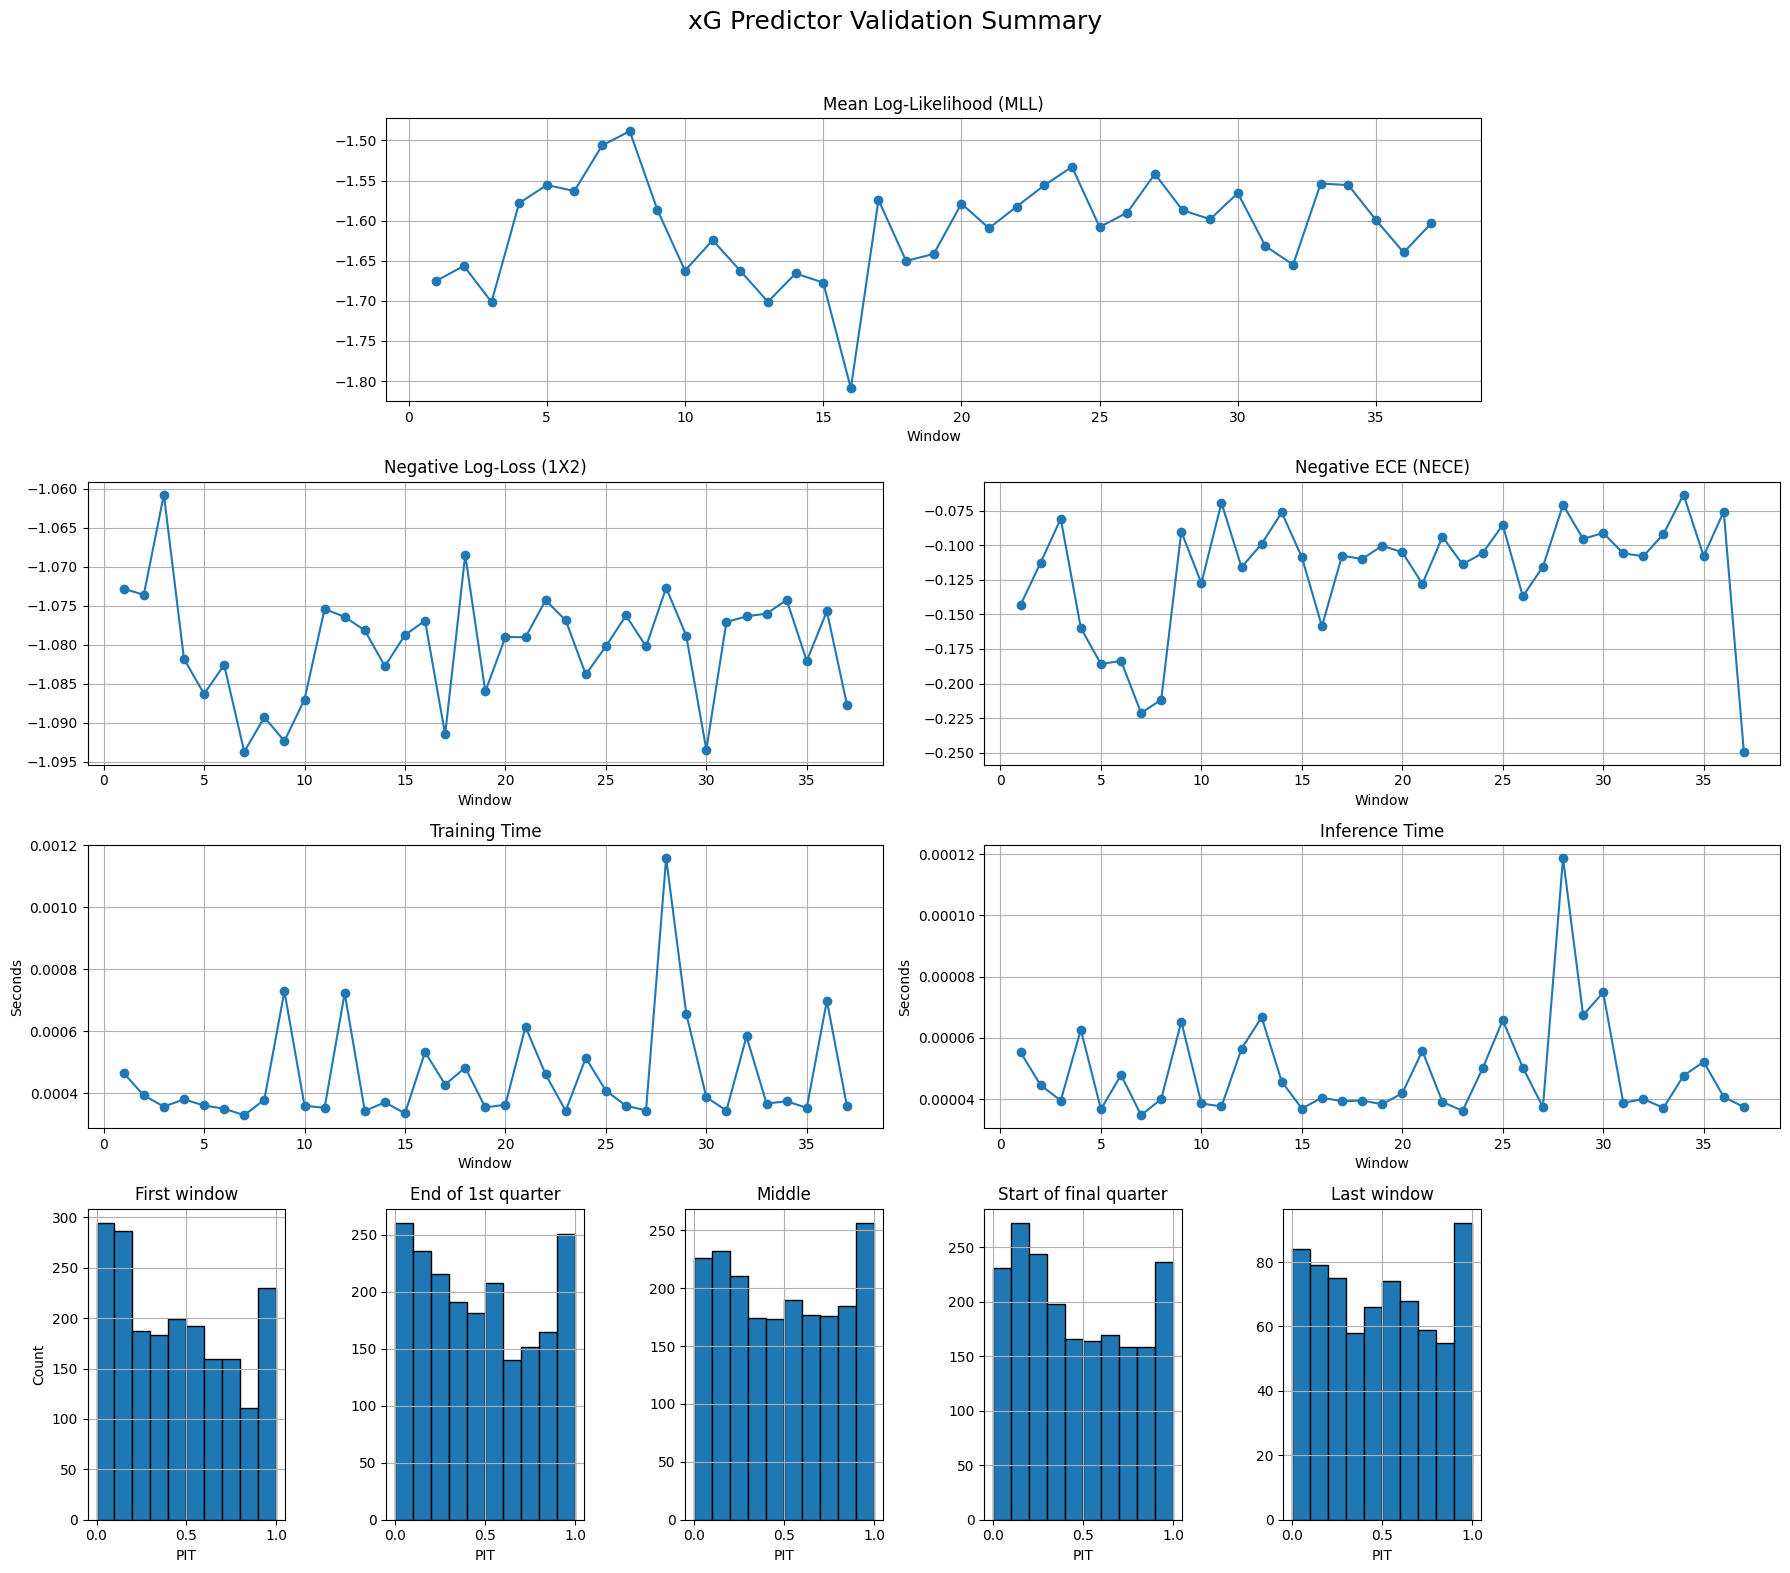

In [55]:
validator = ModelValidator(DummyRegressor, data.entries[features], data.entries['goals_scored'])
validator.validate()
summaries['Dummy Regressor'] = validator.get_summary()
validator.plot_xg_predictor_summary()


(1)
xG Predictor training time: 0.0041
xG Predictor inference time: 0.0008
xG Predictor Mean Log Likelihood: -1.6292
xG Predictor Negative Log-Loss 1X2: -1.0237
xG Predictor Negative Expected Calibration Error: -0.3362

(2)
xG Predictor training time: 0.0022
xG Predictor inference time: 0.0006
xG Predictor Mean Log Likelihood: -1.6023
xG Predictor Negative Log-Loss 1X2: -1.0212
xG Predictor Negative Expected Calibration Error: -0.3623

(3)
xG Predictor training time: 0.0182
xG Predictor inference time: 0.0008
xG Predictor Mean Log Likelihood: -1.6386
xG Predictor Negative Log-Loss 1X2: -0.9966
xG Predictor Negative Expected Calibration Error: -0.3876

(4)
xG Predictor training time: 0.0168
xG Predictor inference time: 0.0008
xG Predictor Mean Log Likelihood: -1.5280
xG Predictor Negative Log-Loss 1X2: -1.0305
xG Predictor Negative Expected Calibration Error: -0.3245

(5)
xG Predictor training time: 0.0027
xG Predictor inference time: 0.0005
xG Predictor Mean Log Likelihood: -1.5198
xG

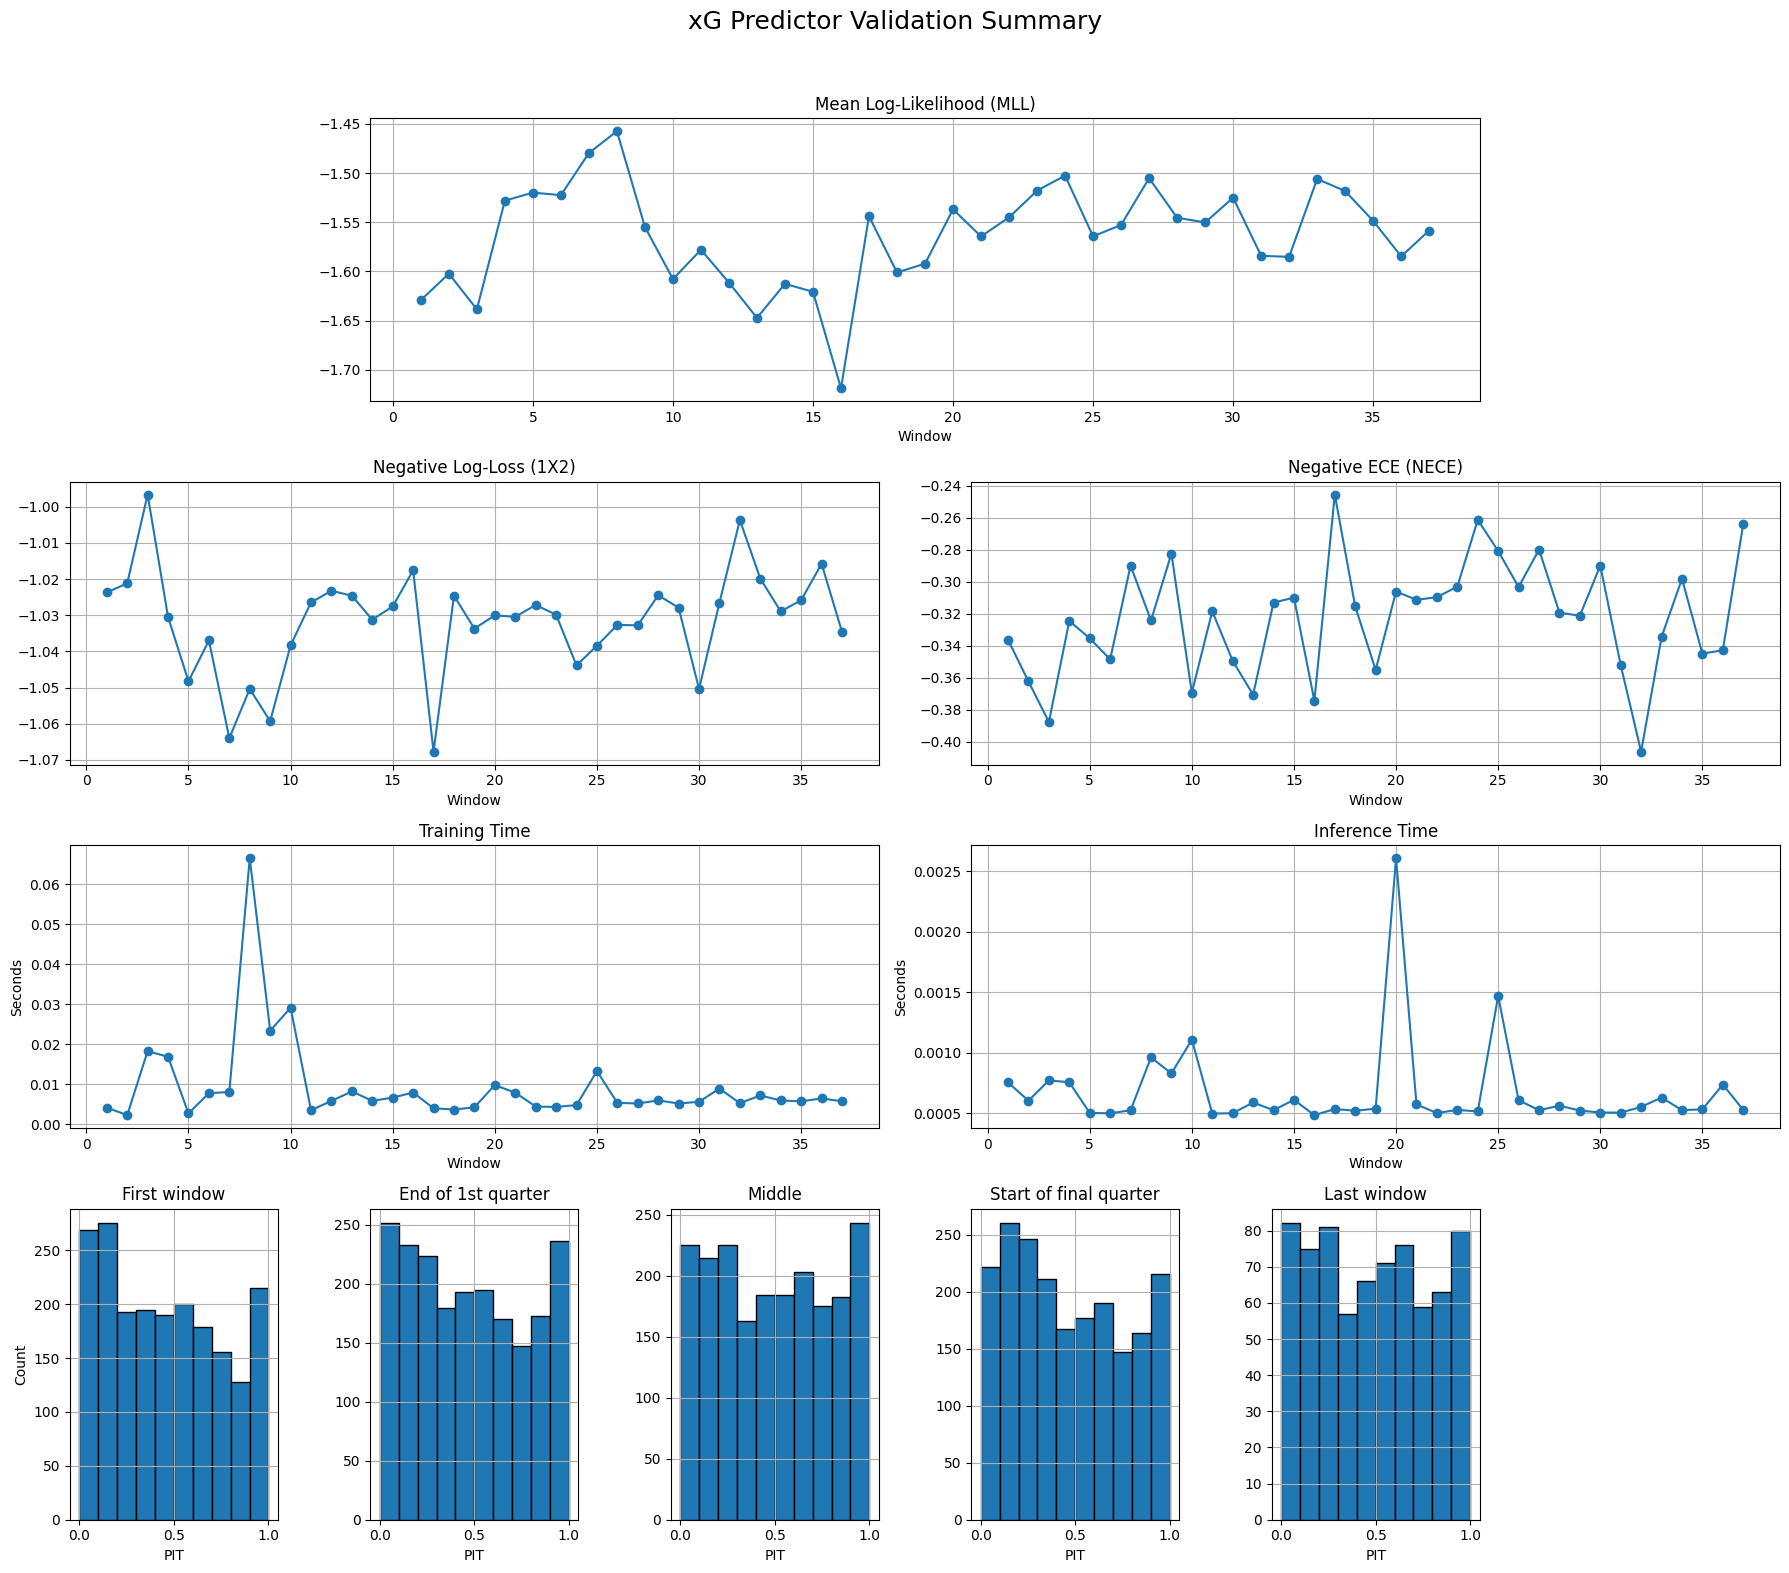

In [56]:
validator = ModelValidator(PoissonRegressor, data.entries[for_maher], data.entries['goals_scored'])
validator.validate()
summaries['Maher Model'] = validator.get_summary()
validator.plot_xg_predictor_summary()


(1)
xG Predictor training time: 0.1491
xG Predictor inference time: 0.0009
xG Predictor Mean Log Likelihood: -1.6065
xG Predictor Negative Log-Loss 1X2: -1.0209
xG Predictor Negative Expected Calibration Error: -0.1275

(2)
xG Predictor training time: 0.0481
xG Predictor inference time: 0.0008
xG Predictor Mean Log Likelihood: -1.5715
xG Predictor Negative Log-Loss 1X2: -1.0185
xG Predictor Negative Expected Calibration Error: -0.0846

(3)
xG Predictor training time: 0.0867
xG Predictor inference time: 0.0009
xG Predictor Mean Log Likelihood: -1.6121
xG Predictor Negative Log-Loss 1X2: -0.9844
xG Predictor Negative Expected Calibration Error: -0.1051

(4)
xG Predictor training time: 0.0311
xG Predictor inference time: 0.0006
xG Predictor Mean Log Likelihood: -1.5160
xG Predictor Negative Log-Loss 1X2: -1.0340
xG Predictor Negative Expected Calibration Error: -0.1396

(5)
xG Predictor training time: 0.0820
xG Predictor inference time: 0.0007
xG Predictor Mean Log Likelihood: -1.5229
xG

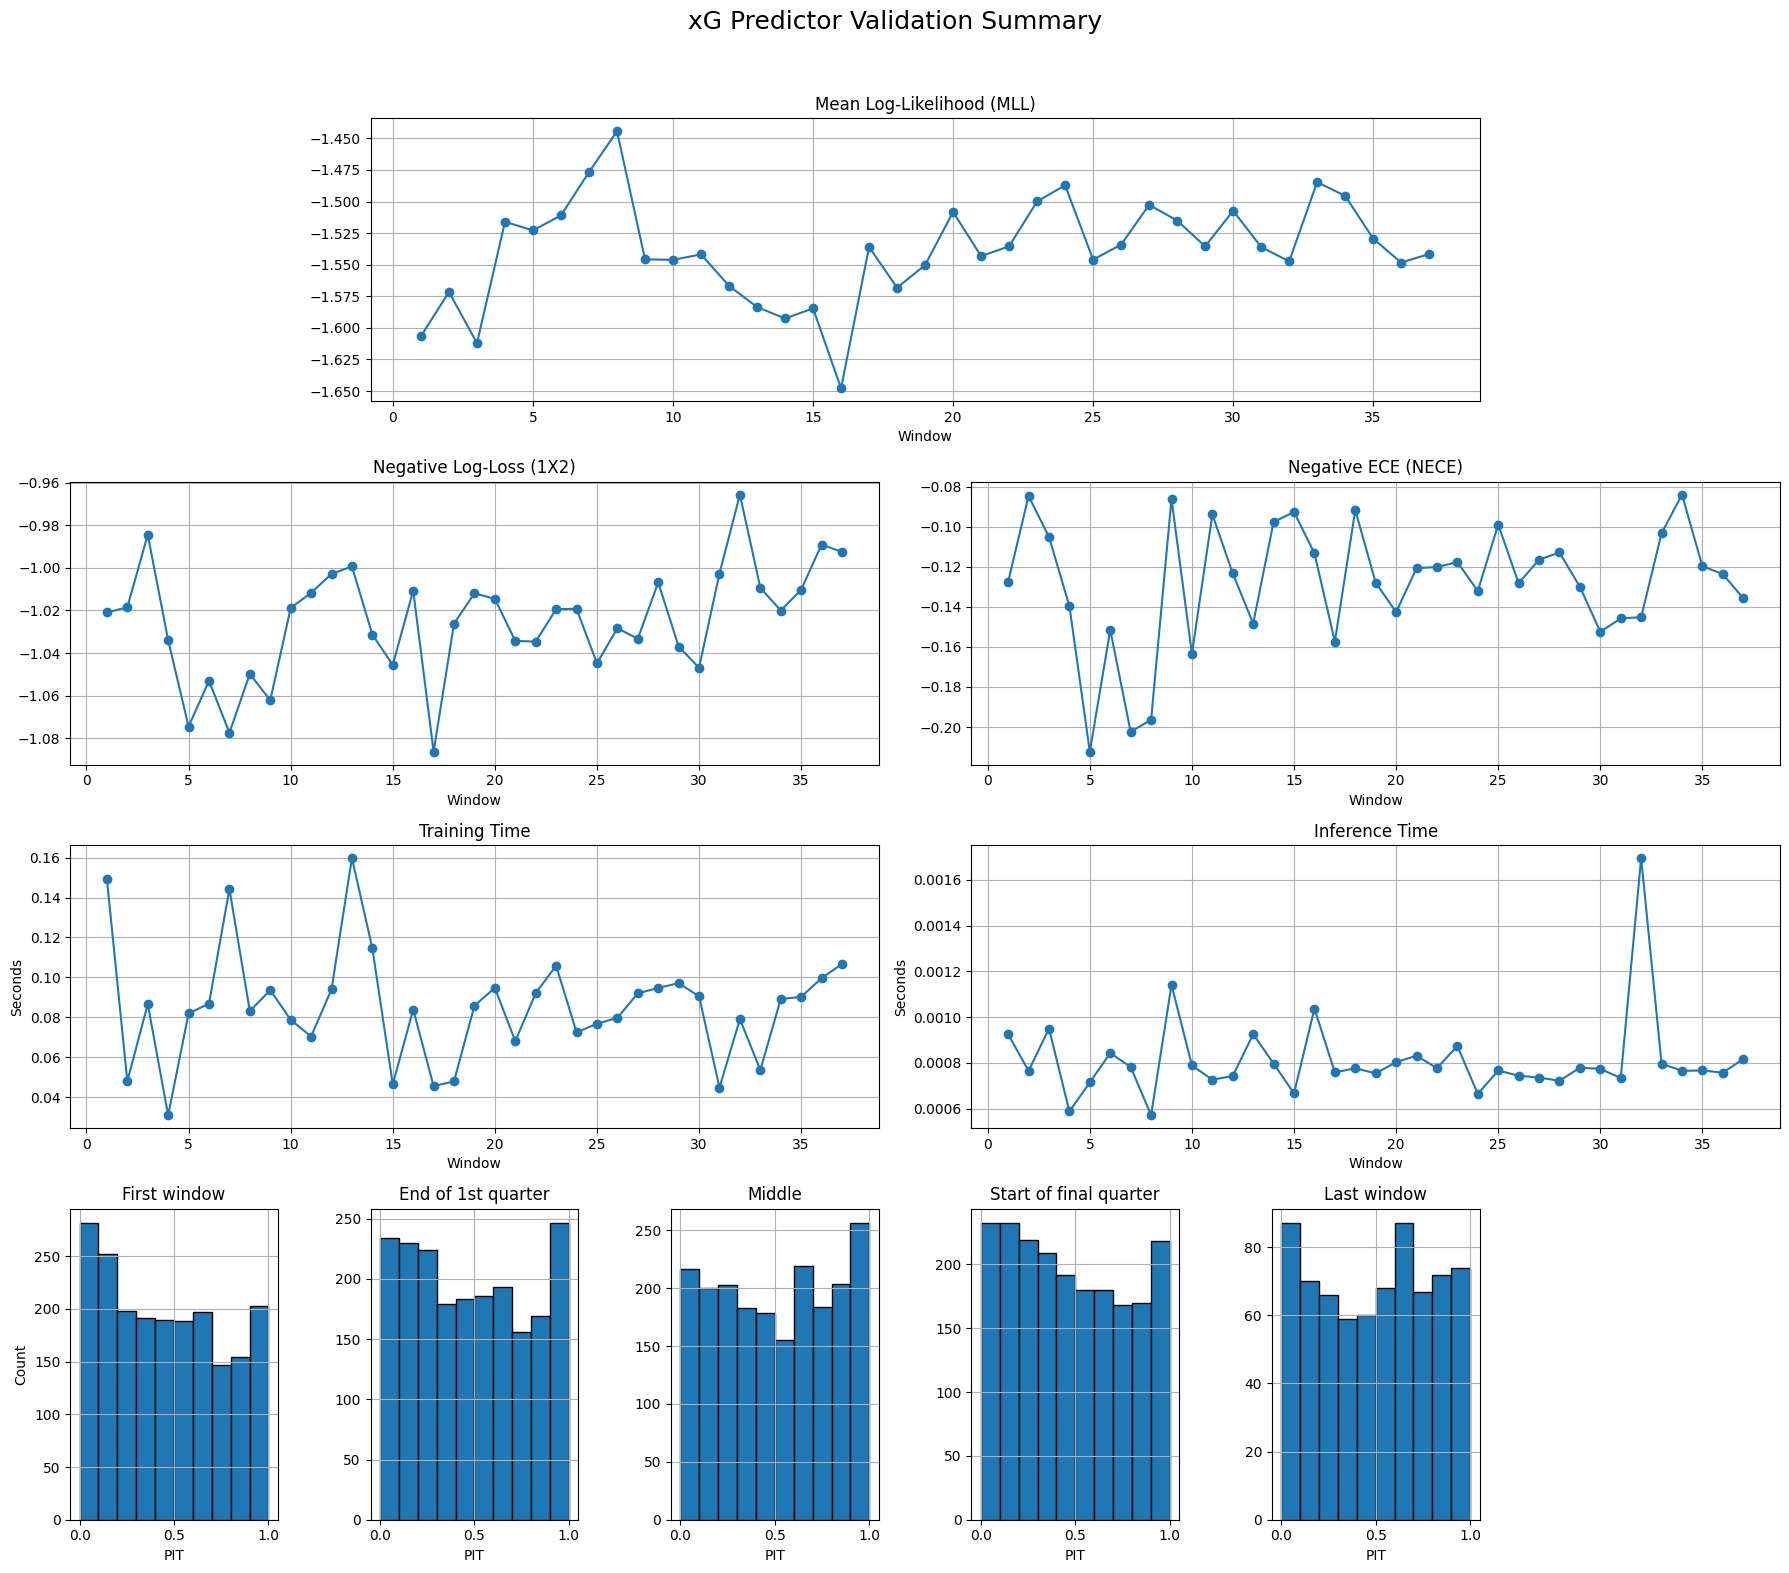

In [57]:
validator = ModelValidator(PoissonRegressor, data.entries[all_features], data.entries['goals_scored'])
validator.validate()
summaries['Poisson Regressor All'] = validator.get_summary()
validator.plot_xg_predictor_summary()


(1)
xG Predictor training time: 0.0040
xG Predictor inference time: 0.0006
xG Predictor Mean Log Likelihood: -1.6369
xG Predictor Negative Log-Loss 1X2: -1.0329
xG Predictor Negative Expected Calibration Error: -0.3193

(2)
xG Predictor training time: 0.0021
xG Predictor inference time: 0.0005
xG Predictor Mean Log Likelihood: -1.6122
xG Predictor Negative Log-Loss 1X2: -1.0334
xG Predictor Negative Expected Calibration Error: -0.2797

(3)
xG Predictor training time: 0.0025
xG Predictor inference time: 0.0005
xG Predictor Mean Log Likelihood: -1.6477
xG Predictor Negative Log-Loss 1X2: -1.0086
xG Predictor Negative Expected Calibration Error: -0.3570

(4)
xG Predictor training time: 0.0024
xG Predictor inference time: 0.0005
xG Predictor Mean Log Likelihood: -1.5375
xG Predictor Negative Log-Loss 1X2: -1.0410
xG Predictor Negative Expected Calibration Error: -0.2658

(5)
xG Predictor training time: 0.0025
xG Predictor inference time: 0.0005
xG Predictor Mean Log Likelihood: -1.5265
xG

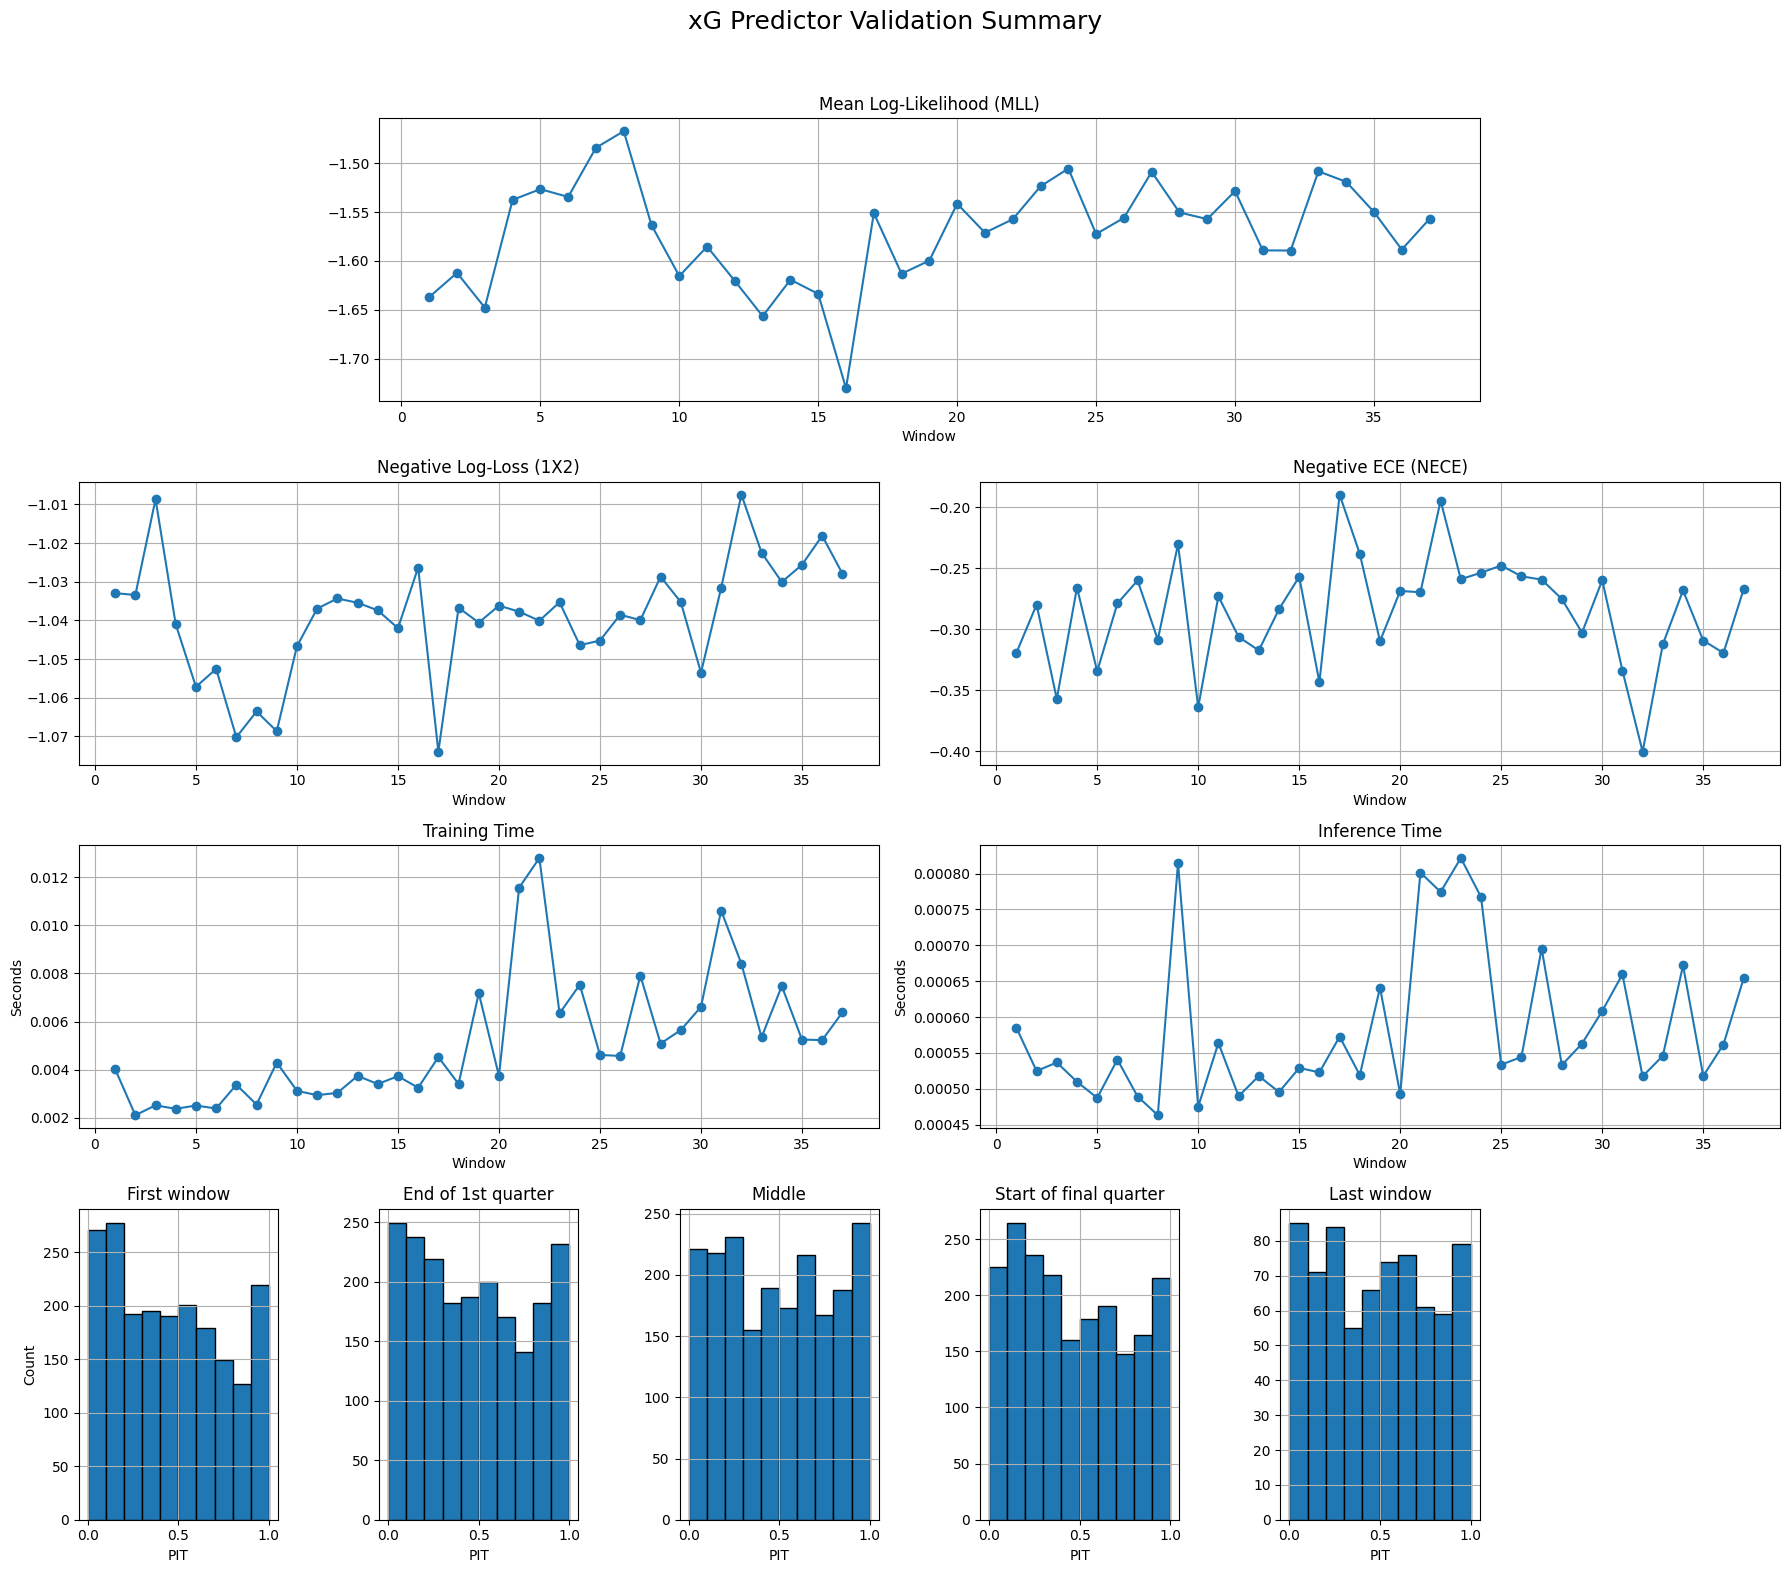

In [58]:
validator = ModelValidator(PoissonRegressor, data.entries[most_features], data.entries['goals_scored'])
validator.validate()
summaries['Poisson Regressor Most'] = validator.get_summary()
validator.plot_xg_predictor_summary()


(1)
xG Predictor training time: 0.1429
xG Predictor inference time: 0.0017
xG Predictor Mean Log Likelihood: -1.6349
xG Predictor Negative Log-Loss 1X2: -1.0245
xG Predictor Negative Expected Calibration Error: -0.1572

(2)
xG Predictor training time: 0.0686
xG Predictor inference time: 0.0016
xG Predictor Mean Log Likelihood: -1.5746
xG Predictor Negative Log-Loss 1X2: -0.9906
xG Predictor Negative Expected Calibration Error: -0.1419

(3)
xG Predictor training time: 0.0729
xG Predictor inference time: 0.0016
xG Predictor Mean Log Likelihood: -1.5826
xG Predictor Negative Log-Loss 1X2: -0.9534
xG Predictor Negative Expected Calibration Error: -0.0749

(4)
xG Predictor training time: 0.0624
xG Predictor inference time: 0.0016
xG Predictor Mean Log Likelihood: -1.4834
xG Predictor Negative Log-Loss 1X2: -1.0028
xG Predictor Negative Expected Calibration Error: -0.1158

(5)
xG Predictor training time: 0.0632
xG Predictor inference time: 0.0016
xG Predictor Mean Log Likelihood: -1.4735
xG

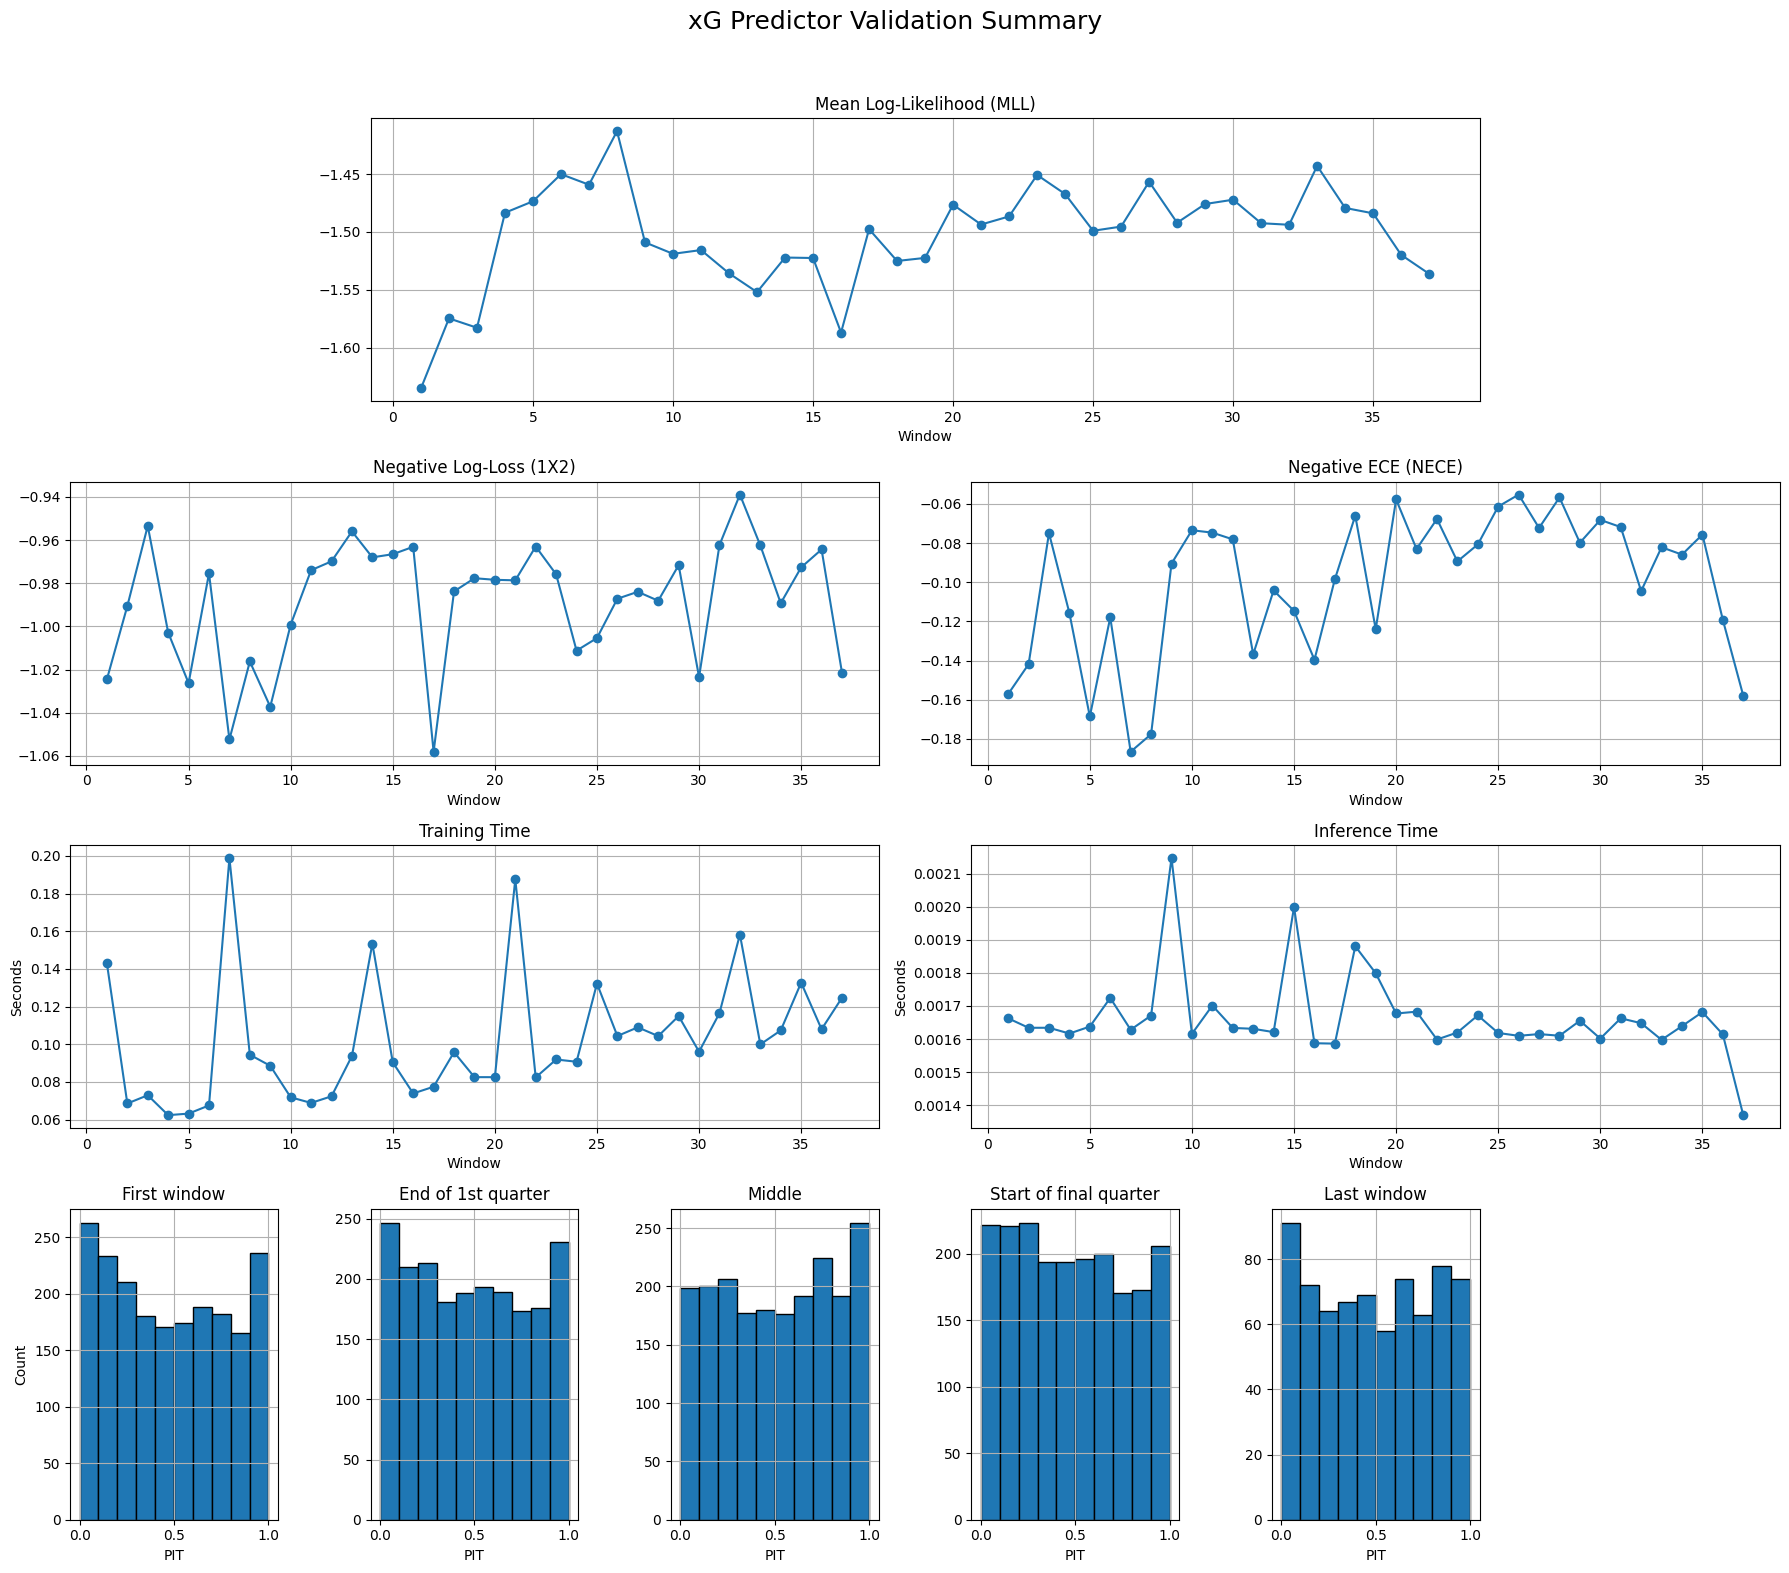

In [59]:
PoissonXGBR = lambda: XGBRegressor(objective='count:poisson', eval_metric='poisson-nloglik',
                                   n_estimators=100, learning_rate=0.1)
validator = ModelValidator(PoissonXGBR, data.entries[for_maher], data.entries['goals_scored'])
validator.validate()
summaries["PXGBR Maher"] = validator.get_summary()
validator.plot_xg_predictor_summary()


(1)
xG Predictor training time: 0.0984
xG Predictor inference time: 0.0017
xG Predictor Mean Log Likelihood: -1.6457
xG Predictor Negative Log-Loss 1X2: -1.0530
xG Predictor Negative Expected Calibration Error: -0.2303

(2)
xG Predictor training time: 0.0666
xG Predictor inference time: 0.0017
xG Predictor Mean Log Likelihood: -1.5854
xG Predictor Negative Log-Loss 1X2: -1.0245
xG Predictor Negative Expected Calibration Error: -0.1260

(3)
xG Predictor training time: 0.0593
xG Predictor inference time: 0.0017
xG Predictor Mean Log Likelihood: -1.6134
xG Predictor Negative Log-Loss 1X2: -0.9814
xG Predictor Negative Expected Calibration Error: -0.1005

(4)
xG Predictor training time: 0.0665
xG Predictor inference time: 0.0018
xG Predictor Mean Log Likelihood: -1.5050
xG Predictor Negative Log-Loss 1X2: -1.0131
xG Predictor Negative Expected Calibration Error: -0.1391

(5)
xG Predictor training time: 0.0699
xG Predictor inference time: 0.0046
xG Predictor Mean Log Likelihood: -1.5009
xG

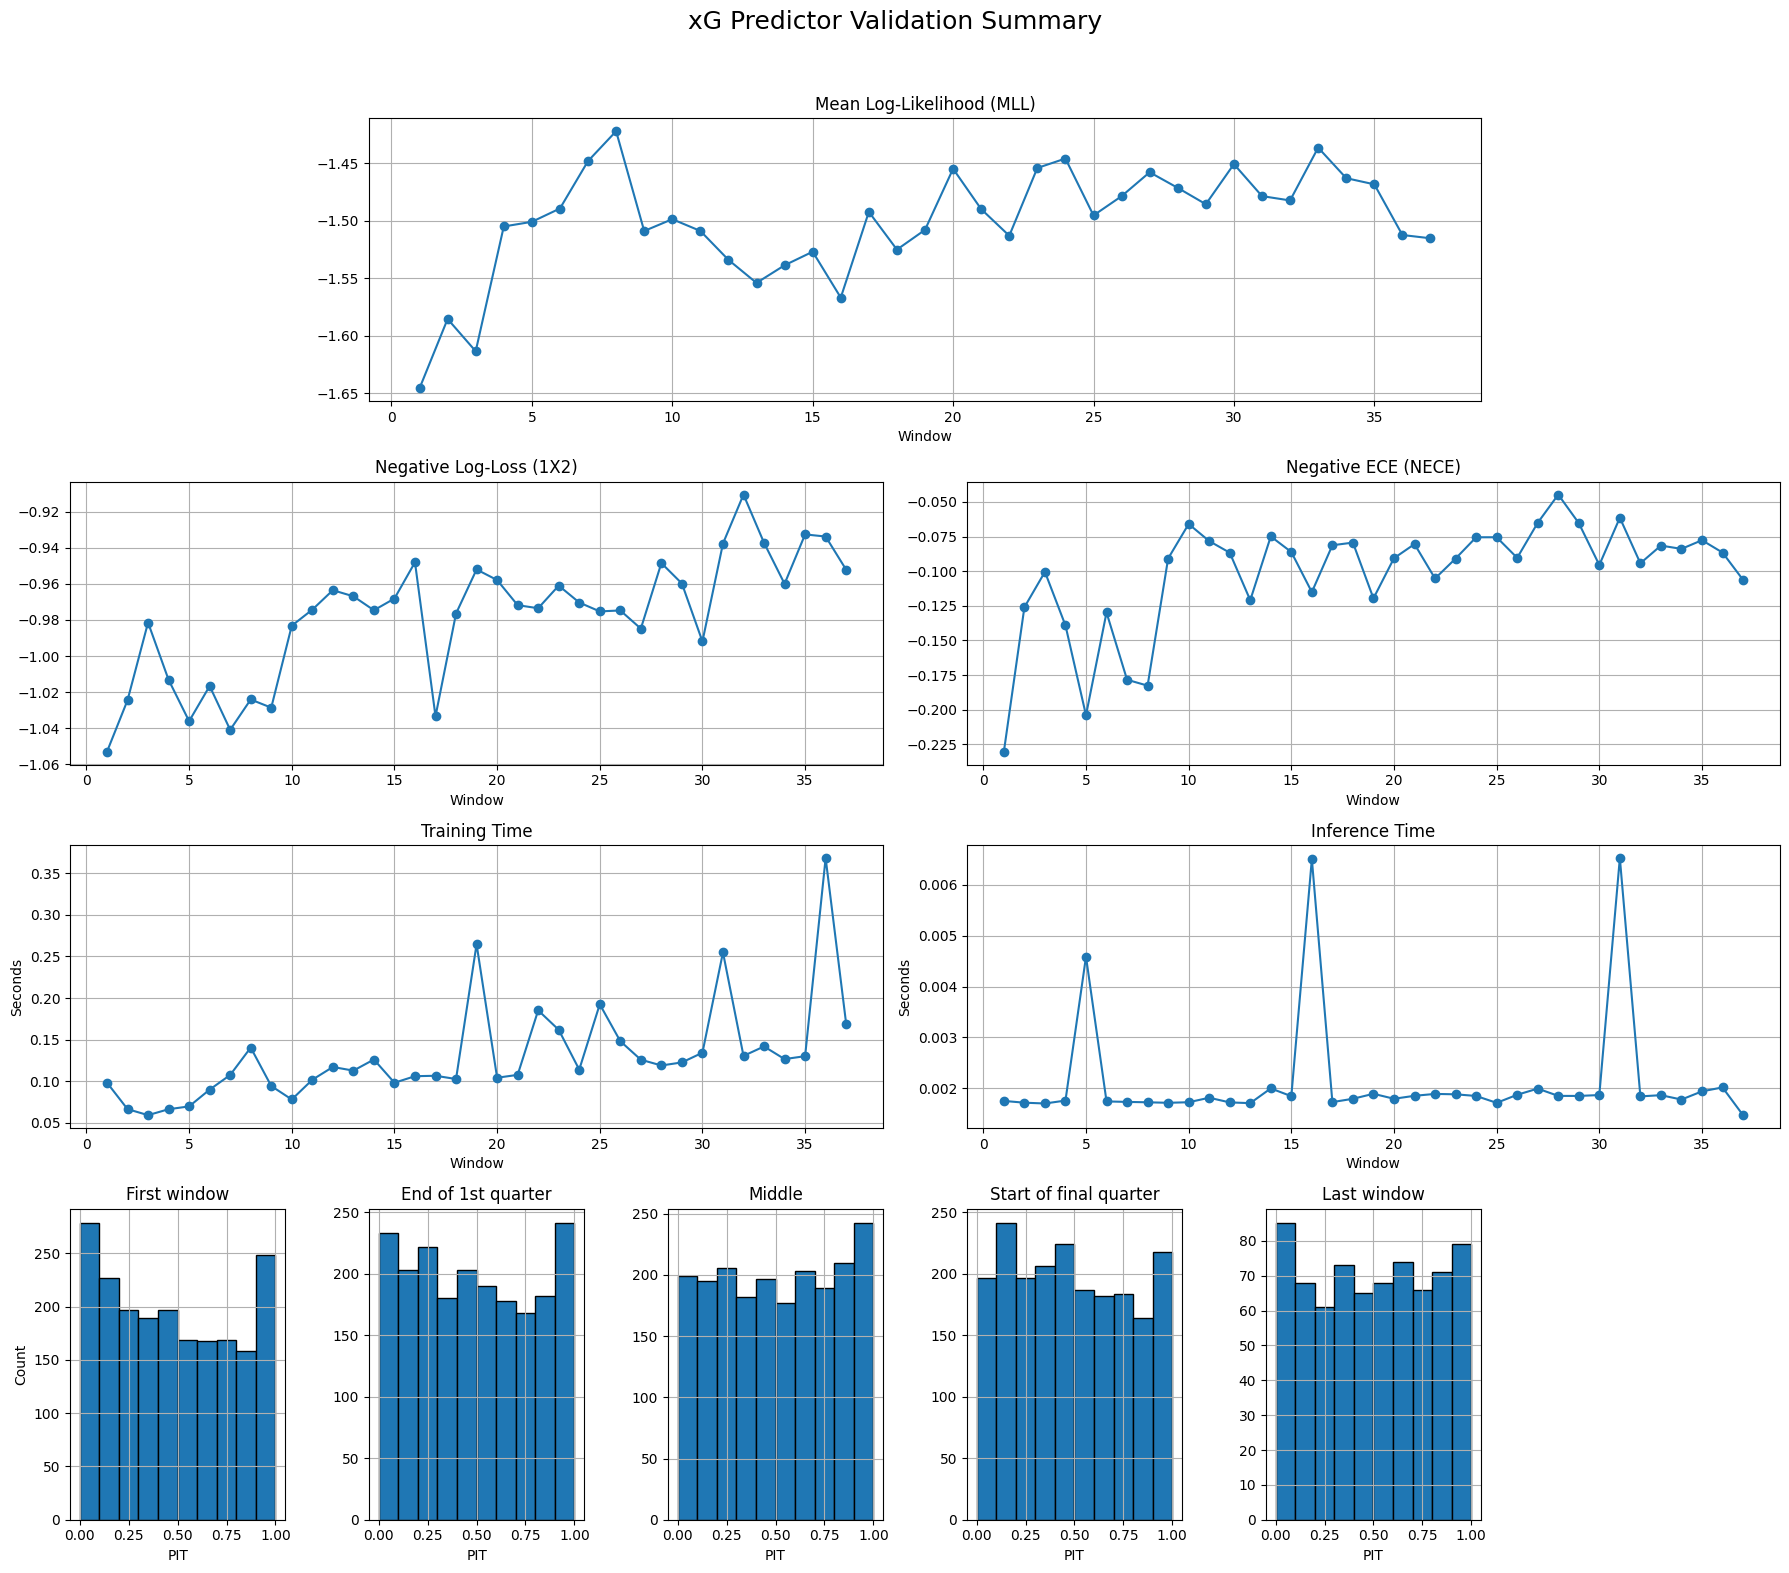

In [60]:
PoissonXGBR = lambda: XGBRegressor(objective='count:poisson', eval_metric='poisson-nloglik',
                                   n_estimators=100, learning_rate=0.1)
validator = ModelValidator(PoissonXGBR, data.entries[all_features], data.entries['goals_scored'])
validator.validate()
summaries["PXGBR All"] = validator.get_summary()
validator.plot_xg_predictor_summary()

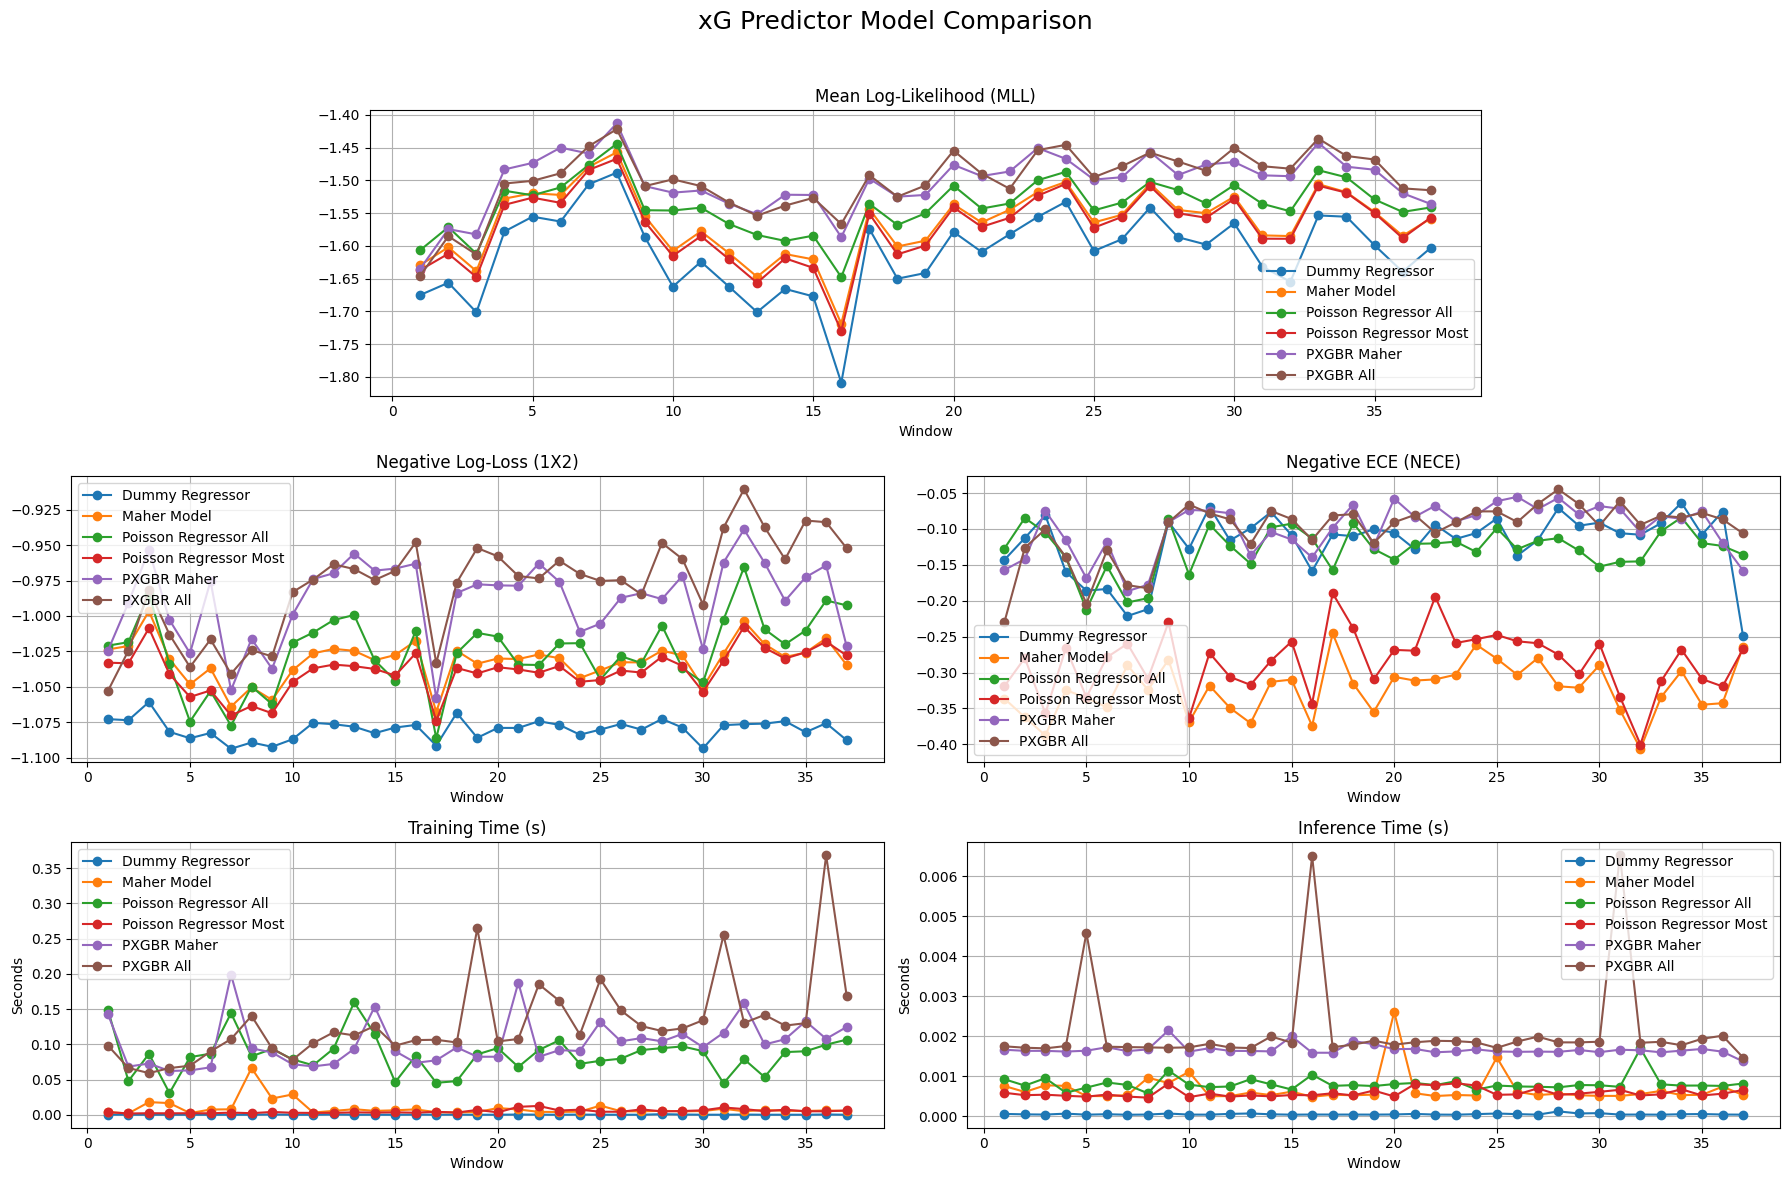

In [61]:
def plot_model_comparison(summaries):
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle("xG Predictor Model Comparison", fontsize=18)

    gs = fig.add_gridspec(
        nrows=3,
        ncols=6,
        height_ratios=[1, 1, 1]
    )

    # ---------- Row 1: MLL (centered) ----------
    ax_mll = fig.add_subplot(gs[0, 1:5])
    for model_name, summary in summaries.items():
        values = summary.get("mlls", [])
        if not values:
            continue
        x = np.arange(1, len(values) + 1)
        ax_mll.plot(x, values, marker='o', label=model_name)

    ax_mll.set_title("Mean Log-Likelihood (MLL)")
    ax_mll.set_xlabel("Window")
    ax_mll.grid(True)
    ax_mll.legend()

    # ---------- Row 2: NLL 1X2 + NECE ----------
    ax_nll1x2 = fig.add_subplot(gs[1, 0:3])
    for model_name, summary in summaries.items():
        values = summary.get("nll1x2", [])
        if not values:
            continue
        x = np.arange(1, len(values) + 1)
        ax_nll1x2.plot(x, values, marker='o', label=model_name)

    ax_nll1x2.set_title("Negative Log-Loss (1X2)")
    ax_nll1x2.set_xlabel("Window")
    ax_nll1x2.grid(True)
    ax_nll1x2.legend()

    ax_nece = fig.add_subplot(gs[1, 3:6])
    for model_name, summary in summaries.items():
        values = summary.get("neces", [])
        if not values:
            continue
        x = np.arange(1, len(values) + 1)
        ax_nece.plot(x, values, marker='o', label=model_name)

    ax_nece.set_title("Negative ECE (NECE)")
    ax_nece.set_xlabel("Window")
    ax_nece.grid(True)
    ax_nece.legend()

    # ---------- Row 3: Times ----------
    ax_train = fig.add_subplot(gs[2, 0:3])
    for model_name, summary in summaries.items():
        values = summary.get("training-times", [])
        if not values:
            continue
        x = np.arange(1, len(values) + 1)
        ax_train.plot(x, values, marker='o', label=model_name)

    ax_train.set_title("Training Time (s)")
    ax_train.set_xlabel("Window")
    ax_train.set_ylabel("Seconds")
    ax_train.grid(True)
    ax_train.legend()

    ax_infer = fig.add_subplot(gs[2, 3:6])
    for model_name, summary in summaries.items():
        values = summary.get("inference-times", [])
        if not values:
            continue
        x = np.arange(1, len(values) + 1)
        ax_infer.plot(x, values, marker='o', label=model_name)

    ax_infer.set_title("Inference Time (s)")
    ax_infer.set_xlabel("Window")
    ax_infer.set_ylabel("Seconds")
    ax_infer.grid(True)
    ax_infer.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


plot_model_comparison(summaries)

In [62]:
def analyze_pxgbr(data, goals, dates, window_length=2000):
    N = len(data)
    n_windows = N // window_length + 1

    lambdas = [None] * window_length
    importances = []
    for i in tqdm(range(n_windows - 1)):
        train_data = data[: (i + 1) * window_length]
        train_goals = goals[: (i + 1) * window_length]

        test_data = data[(i + 1) * window_length: min(N, (i + 2) * window_length)]
        test_goals = goals[(i + 1) * window_length: min(N, (i + 2) * window_length)]
        first_date = dates[(i + 1) * window_length]

        print(f'Window ({i + 1}) - {first_date}')
        
        pxgbr = PoissonXGBR()
        pxgbr.fit(train_data, train_goals)
        test_lambdas = pxgbr.predict(test_data)
        lambdas.extend(test_lambdas)

        test_scores = pairify(test_goals)
        test_lambdas_in_pairs = pairify(test_lambdas)

        imp_dict = {c: imp for c, imp in zip(train_data.columns, pxgbr.feature_importances_)}

        importances.append(imp_dict)

    return lambdas, importances

xgs, importances = analyze_pxgbr(data.entries[all_features], data.entries['goals_scored'], data.entries['date'])

  0%|          | 0/37 [00:00<?, ?it/s]

Window (1) - 1972-09-27
Window (2) - 1975-03-30
Window (3) - 1977-09-18
Window (4) - 1980-03-26
Window (5) - 1982-03-29
Window (6) - 1984-09-12
Window (7) - 1986-06-06
Window (8) - 1988-11-10
Window (9) - 1990-09-12
Window (10) - 1992-10-14
Window (11) - 1994-03-27
Window (12) - 1995-11-22
Window (13) - 1997-02-23
Window (14) - 1998-05-31
Window (15) - 1999-09-26
Window (16) - 2000-10-11
Window (17) - 2001-11-11
Window (18) - 2003-04-02
Window (19) - 2004-06-06
Window (20) - 2005-06-25
Window (21) - 2006-10-11
Window (22) - 2007-12-03
Window (23) - 2008-12-10
Window (24) - 2010-04-03
Window (25) - 2011-06-14
Window (26) - 2012-07-06
Window (27) - 2013-08-14
Window (28) - 2014-11-14
Window (29) - 2016-03-18
Window (30) - 2017-06-06
Window (31) - 2018-09-11
Window (32) - 2019-10-12
Window (33) - 2021-06-28
Window (34) - 2022-06-08
Window (35) - 2023-09-12
Window (36) - 2024-09-10
Window (37) - 2025-10-14


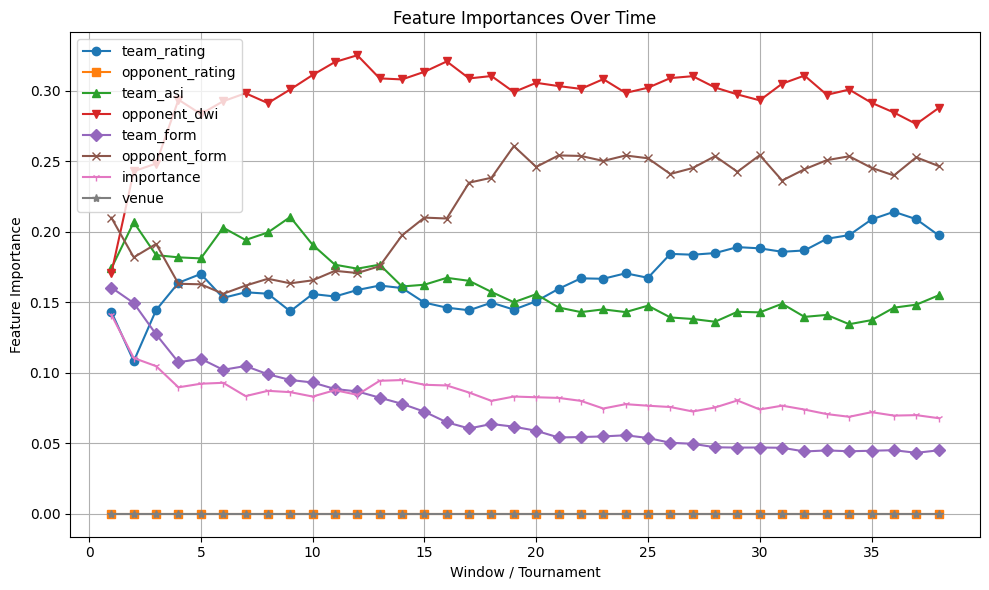

In [64]:
def plot_feature_importance_trends(names, feature_dicts):
    # Extract features
    features = ['team_rating', 'opponent_rating', 'team_asi', 'opponent_dwi', 'team_form', 'opponent_form', 'importance', 'venue']

    # Build a list of values per feature
    feature_values = {f: [] for f in features}
    for fd in feature_dicts:
        for f in features:
            feature_values[f].append(fd.get(f, 0))  # default 0 if missing

    # Plot
    plt.figure(figsize=(10, 6))
    markers = ['o', 's', '^', 'v', 'D', 'x', "1", "*"]  # one marker per feature
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray']

    for f, m, c in zip(features, markers, colors):
        plt.plot(names, feature_values[f], marker=m, linestyle='-', color=c, label=f)

    plt.xlabel("Window / Tournament")
    plt.ylabel("Feature Importance")
    plt.title("Feature Importances Over Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


data.entries['xg'] = xgs
model = PoissonXGBR()
model.fit(data.entries[all_features], data.entries['goals_scored'])
model.predict(data.entries[all_features])
d = {c: i for c, i in zip(features, model.feature_importances_)}
plot_feature_importance_trends(range(1,len(importances) + 2), importances + [d])

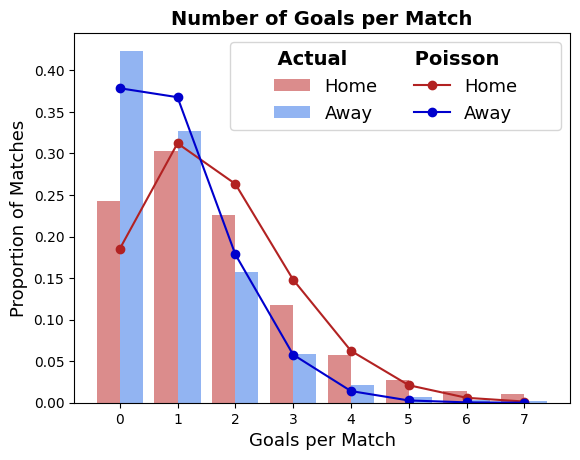

In [71]:
ha = data.results.copy()
ha = ha[ha['neutral'] == False]
ha = ha[['home_score', 'away_score']]

# plot the acutally data
plt.hist(ha.values, bins=range(9), alpha=0.7, label=['Home', 'Away'], density=True, color=["indianred", "cornflowerblue"])

# plot the poisson prediction based the probability mass function
poisson_pred = np.column_stack([[poisson.pmf(i, ha.mean()[j]) for i in range(8)] for j in ha.mean().index])
plt.plot([i-0.5 for i in range(1,9)], poisson_pred[:,0],
                  linestyle='-', marker='o',label="Home", color = 'firebrick')
plt.plot([i-0.5 for i in range(1,9)], poisson_pred[:,1],
                  linestyle='-', marker='o',label="Away", color = 'mediumblue')

# fancify the plot
legend = plt.legend(loc='upper right', fontsize=13, ncol=2)
legend.set_title("      Actual          Poisson        ", prop = {'size':'14', 'weight':'bold'})
plt.xticks([i-0.5 for i in range(1, 9)],[i for i in range(8)])
plt.xlabel("Goals per Match",size=13)
plt.ylabel("Proportion of Matches",size=13)
plt.title("Number of Goals per Match",size=14,fontweight='bold')
plt.show()

In [65]:
class XGBR_Poisson(Model):
    pxgbr = None
    def __init__(self):
        self.xg_model = deepcopy(XGBR_Poisson.pxgbr)

    def feature_extractor(self, match: Match) -> tuple[dict, dict]:
        home_reatures = {
            'team_rating': match.home.rating,
            'team_asi': match.home.asi,
            'opponent_dwi': match.away.dwi,
            'team_form': eval_form(match.home.form),
            'opponent_form': eval_form(match.away.form),
            'importance': 1,
            # 'venue': 0.5, # not taking into account usa,mex,can
        }

        away_reatures = {
            'team_rating': match.away.rating,
            'team_asi': match.away.asi,
            'opponent_dwi': match.home.dwi,
            'team_form': eval_form(match.away.form),
            'opponent_form': eval_form(match.home.form),
            'importance': 1,
#            'venue': 0.5, # not taking into account usa,mex,can
        }

        return home_reatures, away_reatures

    def xg_predictor(self, match_features: dict) -> float:
        return self.xg_model.predict(pd.DataFrame([match_features]))[0]

    def goal_simulator(self, xg: float) -> int:
        # random sample from poisson distribution
        return random.poisson(xg)
        # return int(xg)

    def penalty_simulator(self, *args) -> str:
        # penalties are random enough already
        n = random.random()
        if n < 0.5:
            return 'home'
        else:
            return 'away'

    def feature_updater(self, match: Match):
        df = pd.DataFame([{
            'home_team': match.home.name,
            'away_team': match.away.name,
            'away_rating': match.away.rating,
            'home_rating': match.home.rating,
            ...
        }])
        # TODO apply calculators
        # update global dicts ?OR? individual teams

start = timer()
XGBR_Poisson.pxgbr = PoissonXGBR()
# features = ['team_rating', 'team_asi', 'opponent_dwi', 'team_form', 'opponent_form', 'importance', 'venue']
XGBR_Poisson.pxgbr.fit(data.entries[all_features], data.entries['goals_scored'])
end = timer()
print(end - start)

0.5734850600001664


In [67]:
start = timer()
s = TournamentSimulator(
    num_simulations   = 100,
    teams             = reference.teams,
    gs_lb             = reference.group_stage_leaderboard,
    matches           = reference.matches,
    model             = XGBR_Poisson,
    # max_workers=12
)
s.simulate()
end = timer()
print(end - start)
s.summary

2026-05-27 11:21:51,753 ThreadPoolExecutor-9_0 starting
2026-05-27 11:21:51,774 ThreadPoolExecutor-9_0 tournament created


Simulating:   0%|          | 0/100 [00:00<?, ?it/s]

2026-05-27 11:21:52,748 ThreadPoolExecutor-9_0 simulation done
2026-05-27 11:21:52,767 ThreadPoolExecutor-9_0 starting
2026-05-27 11:21:52,773 ThreadPoolExecutor-9_0 tournament created


Simulating:   0%|          | 0/100 [00:00<?, ?it/s]

2026-05-27 11:21:53,862 ThreadPoolExecutor-9_0 simulation done
2026-05-27 11:21:53,868 ThreadPoolExecutor-9_0 starting
2026-05-27 11:21:53,877 ThreadPoolExecutor-9_0 tournament created


...

Simulating:   0%|          | 0/100 [00:00<?, ?it/s]

2026-05-27 11:22:56,800 ThreadPoolExecutor-9_0 simulation done


Aggregating:   0%|          | 0/100 [00:00<?, ?it/s]

68.14075854000112


,Win,Finals,Semi-Finals,Quarter-Finals,Round of 16,Round of 32
Belgium,13.0,19.0,35.0,53.0,72.0,96.0
Netherlands,12.0,23.0,38.0,55.0,77.0,98.0
Spain,11.0,17.0,30.0,46.0,67.0,97.0
Germany,10.0,17.0,29.0,41.0,64.0,94.0
Portugal,8.0,16.0,21.0,38.0,61.0,90.0
Argentina,8.0,14.0,17.0,29.0,50.0,83.0
Turkey,7.0,12.0,18.0,27.0,55.0,82.0
France,7.0,13.0,17.0,34.0,59.0,92.0
Japan,3.0,5.0,10.0,21.0,45.0,81.0
England,3.0,6.0,15.0,32.0,46.0,89.0
